In this notebook, we are not filtering out any of the data based on the reason size. We're combining both data collection data and app testing data and training ML models for size based fish freshness classification.

In [1]:
import os, shutil
import math
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import display, Image

These are the dates on which sardine app testing was performed with scale         
dates = *['2024-11-26', '2024-11-21', '2024-11-19', '2024-11-14', '2024-11-12',         
        '2024-11-07', '2024-10-29', '2024-10-24', '2024-10-22', '2024-08-13',         
        '2024-08-12', '2024-07-30', '2024-07-16', '2024-07-11', '2024-06-11',         
        '2024-06-04', '2024-05-28', '2024-05-23', '2024-04-05']*

In [ ]:
dates = ['2024-12-03', '2024-12-10', '2024-12-17', '2024-12-19',
         '2024-11-26', '2024-11-21', '2024-11-19', '2024-11-14', '2024-11-12',
         '2024-11-07', '2024-10-29', '2024-10-24', '2024-10-22', '2024-08-13',
         '2024-08-12', '2024-07-30', '2024-07-16', '2024-07-11', '2024-06-11',
         '2024-06-04', '2024-05-28', '2024-05-23', '2024-04-05']

In [ ]:
# src = '/kaggle/input/sardine-app-testing-data-new'
# des = '/kaggle/working/app_testing_data'
# os.makedirs(des, exist_ok=True)

# for date in sorted(dates):
#     sardine = os.path.join(src, date, 'sardine')
#     if os.path.isdir(sardine):
#         for folder in tqdm(os.listdir(sardine), desc=f'{date}'):
#             folder_path = os.path.join(sardine, folder)
#             new_folder_path = os.path.join(des, folder)
#             os.makedirs(new_folder_path, exist_ok=True)
#             shutil.copytree(folder_path, new_folder_path, dirs_exist_ok=True)

# print(len(os.listdir(os.path.join(des, 'Bad'))), len(os.listdir(os.path.join(des, 'Good'))))

# Model Training

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # For saving models
from tqdm import tqdm
import os

# ML classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [32]:
def filter_df_by_date(df, date, greater=False):
    df = df.copy()
    filenames = df['SegmentedFilename']
    df['dates'] = df['SegmentedFilename'].apply(lambda x: x[:10])
    if greater:
        df = df[df['dates']>=date]
    else:
        df = df[df['dates']<=date]
        
    df = df.drop(columns = ['dates'])  # or df = df.drop(columns=['Age'])
    return df

## *scale_based_size_good_data.csv* has good data from August 1 2024 to November 30 2024
## *scale_based_size_good_app_data.csv* has data from April 1 2024 to December 19 2024
## december data is only from dec-01-24 to dec-26-24

In [33]:
good_data = pd.read_csv('/kaggle/input/unseen-tomato-images-dataset/scale_based_size_good_data.csv')
bad_data = pd.read_csv('/kaggle/input/unseen-tomato-images-dataset/scale_based_size_bad_data.csv')

good_app = pd.read_csv('/kaggle/input/unseen-tomato-images-dataset/scale_based_size_good_app_data.csv')
bad_app = pd.read_csv('/kaggle/input/unseen-tomato-images-dataset/scale_based_size_bad_app_data.csv')

good_dec = pd.read_csv('/kaggle/input/unseen-tomato-images-dataset/scale_based_size_good_data_dec.csv')
bad_dec = pd.read_csv('/kaggle/input/unseen-tomato-images-dataset/scale_based_size_bad_data_dec.csv')

good_app_old = filter_df_by_date(good_app, '2024-08-13', greater=False)
bad_app_old = filter_df_by_date(bad_app, '2024-08-13', greater=False)

good_app_new = filter_df_by_date(good_app, '2024-08-13', greater=True)
bad_app_new = filter_df_by_date(bad_app, '2024-08-13', greater=True)

good_app_new2 = filter_df_by_date(good_app, '2024-12-02', greater=True)
bad_app_new2 = filter_df_by_date(bad_app, '2024-12-02', greater=True)

# good_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_good_app_data_dec20tojan7.csv')
# bad_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_bad_app_data_dec20tojan7.csv')

# good_app_new3 = filter_df_by_date(good_app, '2024-12-02', greater=True)
# bad_app_new3 = filter_df_by_date(bad_app, '2024-12-02', greater=True)

## *scale_based_size_good_app_data_dec20tojan7.csv* are actually till Jan 22 2025

In [34]:
good_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_good_app_data_dec20tojan7.csv')
bad_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_bad_app_data_dec20tojan7.csv')

def filter_df(df, date):
    df = df.copy()
    filenames = df['SegmentedFilename']
    df['dates'] = df['SegmentedFilename'].apply(lambda x: x[:10])
    df = df[df['dates']==date]
    df.drop(columns=['dates'], inplace=True)
    return df

# good_app_new3 = filter_df(good_app_new3, '2024-12-26')
# bad_app_new3 = filter_df(bad_app_new3, '2024-12-26')

good_app_new3_jan2 = filter_df(good_app_new3, '2025-01-02')
bad_app_new3_jan2 = filter_df(bad_app_new3, '2025-01-02')

good_app_new3_dec26 = filter_df(good_app_new3, '2024-12-26')
bad_app_new3_dec26 = filter_df(bad_app_new3, '2024-12-26')

good_app_new3_dec24 = filter_df(good_app_new3, '2024-12-24')
bad_app_new3_dec24 = filter_df(bad_app_new3, '2024-12-24')

In [61]:
good_app_new3_jan2[good_app_new3_jan2['ScaleDetected']=='no'].shape

(8, 14)

In [62]:
# good = pd.read_csv('/kaggle/working/scale_based_size_good_data.csv')
# bad = pd.read_csv('/kaggle/working/scale_based_size_bad_data.csv')

# good_app = pd.read_csv('/kaggle/working/scale_based_size_good_app_data.csv')
# bad_app = pd.read_csv('/kaggle/working/scale_based_size_bad_app_data.csv')

# good_dec = pd.read_csv('/kaggle/working/scale_based_size_good_data_dec.csv')
# bad_dec = pd.read_csv('/kaggle/working/scale_based_size_bad_data_dec.csv')

In [35]:
cols_to_drop = ['FishDetected', 'SegmentedFilename', 'ScaleDetected']

good_data.dropna(inplace=True)
bad_data.dropna(inplace=True)

good_data.drop(columns=cols_to_drop, inplace=True)
bad_data.drop(columns=cols_to_drop, inplace=True)

print("data collection", good_data.shape, bad_data.shape)

good_app.dropna(inplace=True)
bad_app.dropna(inplace=True)

good_app.drop(columns=cols_to_drop, inplace=True)
bad_app.drop(columns=cols_to_drop, inplace=True)

print("app test data till dec-22-24", good_app.shape, bad_app.shape)

good_app_old.dropna(inplace=True)
bad_app_old.dropna(inplace=True)

good_app_old.drop(columns=cols_to_drop, inplace=True)
bad_app_old.drop(columns=cols_to_drop, inplace=True)

print("app test data till aug-13-24", good_app_old.shape, bad_app_old.shape)

good_dec.dropna(inplace=True)
bad_dec.dropna(inplace=True)

good_dec.drop(columns=cols_to_drop, inplace=True)
bad_dec.drop(columns=cols_to_drop, inplace=True)

print("dec data collection", good_dec.shape, bad_dec.shape)

good_app_new.dropna(inplace=True)
bad_app_new.dropna(inplace=True)

good_app_new.drop(columns=cols_to_drop, inplace=True)
bad_app_new.drop(columns=cols_to_drop, inplace=True)

print("app test data from aug-13-24", good_app_new.shape, bad_app_new.shape)

good_app_new2.dropna(inplace=True)
bad_app_new2.dropna(inplace=True)

good_app_new2.drop(columns=cols_to_drop, inplace=True)
bad_app_new2.drop(columns=cols_to_drop, inplace=True)

print("app test data from dec-02-24", good_app_new2.shape, bad_app_new2.shape)

good_app_new3_jan2.dropna(inplace=True)
bad_app_new3_jan2.dropna(inplace=True)

good_app_new3_jan2.drop(columns=cols_to_drop, inplace=True)
bad_app_new3_jan2.drop(columns=cols_to_drop, inplace=True)

print("app test data on jan-02-25", good_app_new3_jan2.shape, bad_app_new3_jan2.shape)

good_app_new3_dec26.dropna(inplace=True)
bad_app_new3_dec26.dropna(inplace=True)

good_app_new3_dec26.drop(columns=cols_to_drop, inplace=True)
bad_app_new3_dec26.drop(columns=cols_to_drop, inplace=True)

print("app test data on dec-26-24", good_app_new3_dec26.shape, bad_app_new3_dec26.shape)


good_app_new3_dec24.dropna(inplace=True)
bad_app_new3_dec24.dropna(inplace=True)

good_app_new3_dec24.drop(columns=cols_to_drop, inplace=True)
bad_app_new3_dec24.drop(columns=cols_to_drop, inplace=True)

print("app test data on dec-24-24", good_app_new3_dec24.shape, bad_app_new3_dec24.shape)

good_app_new3.dropna(inplace=True)
bad_app_new3.dropna(inplace=True)

good_app_new3.drop(columns=cols_to_drop, inplace=True)
bad_app_new3.drop(columns=cols_to_drop, inplace=True)

print("app test data from dec-24-24", good_app_new3.shape, bad_app_new3.shape)

data collection (2258, 11) (1937, 11)
app test data till dec-22-24 (1321, 11) (666, 11)
app test data till aug-13-24 (252, 11) (385, 11)
dec data collection (720, 11) (233, 11)
app test data from aug-13-24 (1084, 11) (297, 11)
app test data from dec-02-24 (168, 11) (194, 11)
app test data on jan-02-25 (79, 11) (12, 11)
app test data on dec-26-24 (86, 11) (48, 11)
app test data on dec-24-24 (62, 11) (26, 11)
app test data from dec-24-24 (489, 11) (164, 11)


In [ ]:
d = {'2025-01-02': {'good':72, 'bad':13},
     '2024-12-24': {'good':54, 'bad':20},
     '2024-12-26': {'good':84, 'bad':50}}

In [36]:
# good_app = filter_df_by_date(good_app, '2024-12-01')
# bad_app = filte_df_by_date(bad_app, '2024-12-01')

good = pd.concat([good_data, good_dec, good_app, good_app_new3], ignore_index=True)
bad = pd.concat([bad_data, bad_dec, bad_app, bad_app_new3], ignore_index=True)

# good = pd.concat([good_data, good_app], ignore_index=True)
# bad = pd.concat([bad_data, bad_app], ignore_index=True)

# good = pd.concat([good, good_dec], ignore_index=True)
# bad = pd.concat([bad, bad_dec], ignore_index=True)

# good = pd.concat([good, good_app, good_dec], ignore_index=True)
# bad = pd.concat([bad, bad_app, bad_dec], ignore_index=True)

# good = pd.read_csv('/kaggle/working/scale_based_size_good_data_dec.csv')
# bad = pd.read_csv('/kaggle/working/scale_based_size_bad_data_dec.csv')

# good = pd.read_csv('/kaggle/working/scale_based_size_good_app_data.csv')
# bad = pd.read_csv('/kaggle/working/scale_based_size_bad_app_data.csv')

# good = good_dec
# bad = bad_dec

good.shape, bad.shape

((4788, 11), (3000, 11))

In [37]:
# Models dictionary
# models = {
#     "LogisticRegression": LogisticRegression(),
#     "RandomForestClassifier": RandomForestClassifier(),
#     "SVC": SVC(),
#     "KNeighborsClassifier": KNeighborsClassifier(),
#     "DecisionTreeClassifier": DecisionTreeClassifier(),
#     "GradientBoostingClassifier": GradientBoostingClassifier(),
#     "GaussianNB": GaussianNB(),
#     "XGBClassifier": XGBClassifier(),
#     "AdaBoostClassifier": AdaBoostClassifier(),
#     "ExtraTreesClassifier": ExtraTreesClassifier()
# }

models = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42),  # Only if probability=True is used, otherwise no effect.
    "KNeighborsClassifier": KNeighborsClassifier(), # KNN is deterministic
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "GaussianNB": GaussianNB(), # GaussianNB is deterministic
    "XGBClassifier": XGBClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42)
}

def prepare_data(good_df, bad_df):
    # Combine good and bad data, add a label column: 1 for good, 0 for bad
    good_df['label'] = 1
    bad_df['label'] = 0

    # Concatenate good and bad dataframes
    combined_df = pd.concat([good_df, bad_df], ignore_index=True)

    # Shuffle the data
    combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Drop columns that are not features (like 'filename', 'filepath')
    X = combined_df.drop(columns=['label'])
    y = combined_df['label']

    return X, y

def train_and_evaluate_models(X, y, models, model_save_dir):
    # Split data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Standardize the features for models that require scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save the scaler to a file
    scaler_file = f"{model_save_dir}/scaler_classification.pkl"
    joblib.dump(scaler, scaler_file)
    print(f"Saved scaler to {scaler_file}")

    # Train and evaluate models
    for model_name, model in tqdm(models.items()):
        # Use scaled data for models that benefit from scaling
        if model_name in ["LogisticRegression", "SVC", "KNeighborsClassifier",
                          "GradientBoostingClassifier", "XGBClassifier"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            # For tree-based models, use original data
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        # Save the model
        model_file = f"{model_save_dir}/{model_name}.pkl"
        joblib.dump(model, model_file)
        print(f"Saved {model_name} to {model_file}")

        # Plot confusion matrix
        plot_confusion_matrix(y_test, y_pred, model_name)

        # Print classification report
        print(f"Classification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [38]:
def load_and_evaluate_models(unseen_X, unseen_y, model_save_dir, model_names, scaler_path=None):
    # Load the scaler or preprocessor if it exists
    if scaler_path:
        scaler = joblib.load(scaler_path)
        unseen_X_scaled = scaler.transform(unseen_X)  # Apply the same scaling to unseen data

    # Iterate over all the saved models and evaluate them
    for model_name in model_names:
        # Load the model from the file
        model_path = f"{model_save_dir}/{model_name}.pkl"
        model = joblib.load(model_path)
        if model_name in ["LogisticRegression", "SVC", "KNeighborsClassifier",
                  "GradientBoostingClassifier", "XGBClassifier"]:
            y_pred = model.predict(unseen_X_scaled)
        else:
            # For tree-based models, use original data
            y_pred = model.predict(unseen_X)

        # Plot confusion matrix
        plot_confusion_matrix(unseen_y, y_pred, model_name)

        # Print classification report
        print(f"Classification Report for {model_name} on Unseen Data:\n")
        print(classification_report(unseen_y, y_pred, target_names=['Bad', 'Good']))


# Example usage
model_save_dir = '/kaggle/working/Classification models'
scaler_path = '/kaggle/working/Classification models/scaler_classification.pkl'  # Path to the saved scaler used during training

model_names = [
    "LogisticRegression", "RandomForestClassifier", "SVC", "KNeighborsClassifier",
    "DecisionTreeClassifier", "GradientBoostingClassifier", "GaussianNB",
    "XGBClassifier", "AdaBoostClassifier", "ExtraTreesClassifier"
]

In [39]:
good_df = good.sample(frac=1, random_state=42).reset_index(drop=True)
bad_df = bad.sample(frac=1, random_state=42).reset_index(drop=True)
model_save_dir = '/kaggle/working/Classification models'
os.makedirs(model_save_dir, exist_ok=True)

In [40]:
unseen_X, unseen_y = prepare_data(good_df[:100], bad_df[:100])
# unseen_X, unseen_y = prepare_data(good_df[:10], bad_df[:10])

print(unseen_X.shape, unseen_y.shape)

(200, 11) (200,)


/tmp/ipykernel_34/1856496663.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_df['label'] = 1
/tmp/ipykernel_34/1856496663.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bad_df['label'] = 0


In [41]:
last_index = min(good_df.shape[0], bad_df.shape[0])
last_index

3000

In [42]:
unseen_X_2, unseen_y_2 = prepare_data(good_df[last_index:], bad_df[-10:])
unseen_X_2.shape, unseen_y_2.shape

/tmp/ipykernel_34/1856496663.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_df['label'] = 1
/tmp/ipykernel_34/1856496663.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bad_df['label'] = 0


((1798, 11), (1798,))

In [43]:
# X, y = prepare_data(good_df[50:last_index], bad_df[50:last_index])
X, y = prepare_data(good_df[100:last_index], bad_df[100:last_index])

print(X.shape, y.shape)

(5800, 11) (5800,)


/tmp/ipykernel_34/1856496663.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_df['label'] = 1
/tmp/ipykernel_34/1856496663.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bad_df['label'] = 0


In [44]:
y.value_counts()

label
0    2900
1    2900
Name: count, dtype: int64

In [45]:
X.columns

Index(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'OnePixelValue',
       'Circumference(cm)', 'Area(cm)', 'AspectRatio', 'DiagonalToHeightRatio',
       'AreaRatio'],
      dtype='object')

## Training

Saved scaler to /kaggle/working/Classification models/scaler_classification.pkl


  0%|          | 0/10 [00:00<?, ?it/s]

Saved LogisticRegression to /kaggle/working/Classification models/LogisticRegression.pkl


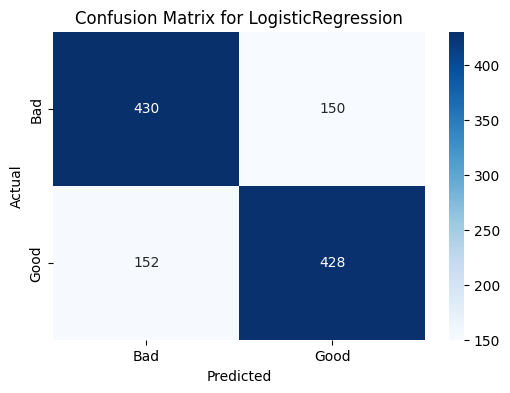

 10%|█         | 1/10 [00:00<00:03,  2.44it/s]

Classification Report for LogisticRegression:

              precision    recall  f1-score   support

         Bad       0.74      0.74      0.74       580
        Good       0.74      0.74      0.74       580

    accuracy                           0.74      1160
   macro avg       0.74      0.74      0.74      1160
weighted avg       0.74      0.74      0.74      1160

Saved RandomForestClassifier to /kaggle/working/Classification models/RandomForestClassifier.pkl


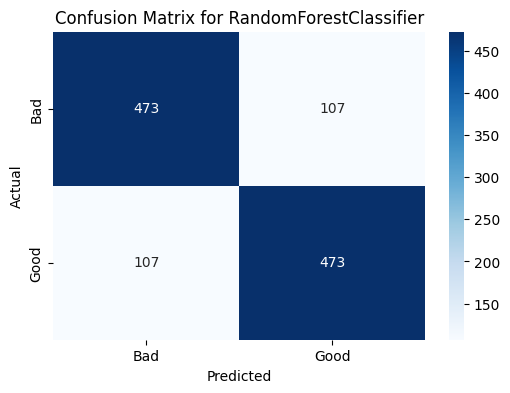

 20%|██        | 2/10 [00:01<00:06,  1.29it/s]

Classification Report for RandomForestClassifier:

              precision    recall  f1-score   support

         Bad       0.82      0.82      0.82       580
        Good       0.82      0.82      0.82       580

    accuracy                           0.82      1160
   macro avg       0.82      0.82      0.82      1160
weighted avg       0.82      0.82      0.82      1160

Saved SVC to /kaggle/working/Classification models/SVC.pkl


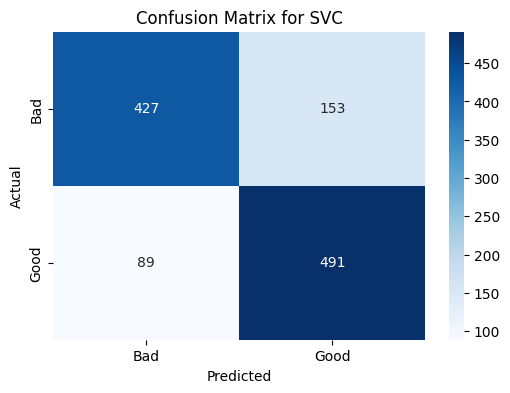

 30%|███       | 3/10 [00:02<00:06,  1.07it/s]

Classification Report for SVC:

              precision    recall  f1-score   support

         Bad       0.83      0.74      0.78       580
        Good       0.76      0.85      0.80       580

    accuracy                           0.79      1160
   macro avg       0.79      0.79      0.79      1160
weighted avg       0.79      0.79      0.79      1160

Saved KNeighborsClassifier to /kaggle/working/Classification models/KNeighborsClassifier.pkl


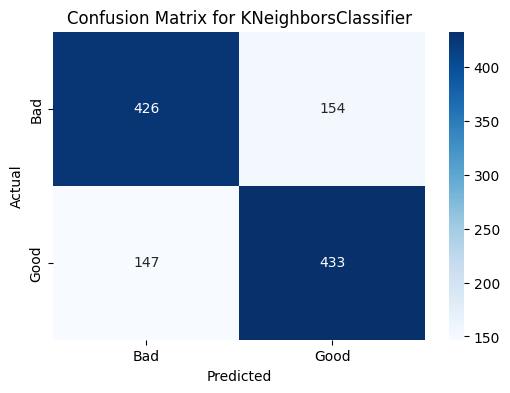

 40%|████      | 4/10 [00:02<00:03,  1.51it/s]

Classification Report for KNeighborsClassifier:

              precision    recall  f1-score   support

         Bad       0.74      0.73      0.74       580
        Good       0.74      0.75      0.74       580

    accuracy                           0.74      1160
   macro avg       0.74      0.74      0.74      1160
weighted avg       0.74      0.74      0.74      1160

Saved DecisionTreeClassifier to /kaggle/working/Classification models/DecisionTreeClassifier.pkl


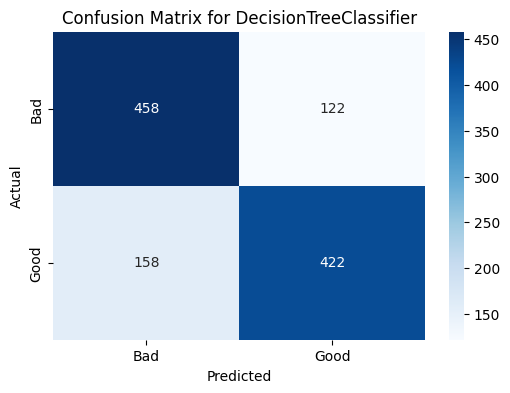

 50%|█████     | 5/10 [00:02<00:02,  2.03it/s]

Classification Report for DecisionTreeClassifier:

              precision    recall  f1-score   support

         Bad       0.74      0.79      0.77       580
        Good       0.78      0.73      0.75       580

    accuracy                           0.76      1160
   macro avg       0.76      0.76      0.76      1160
weighted avg       0.76      0.76      0.76      1160

Saved GradientBoostingClassifier to /kaggle/working/Classification models/GradientBoostingClassifier.pkl


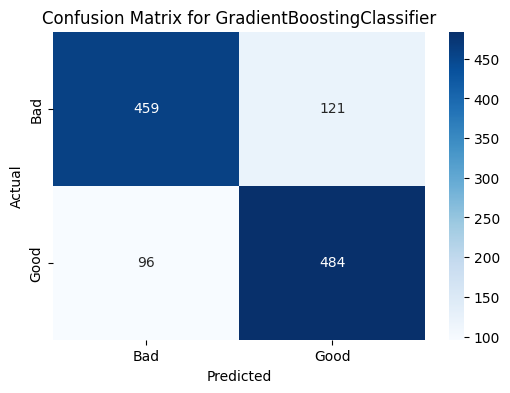

 60%|██████    | 6/10 [00:03<00:02,  1.55it/s]

Classification Report for GradientBoostingClassifier:

              precision    recall  f1-score   support

         Bad       0.83      0.79      0.81       580
        Good       0.80      0.83      0.82       580

    accuracy                           0.81      1160
   macro avg       0.81      0.81      0.81      1160
weighted avg       0.81      0.81      0.81      1160

Saved GaussianNB to /kaggle/working/Classification models/GaussianNB.pkl


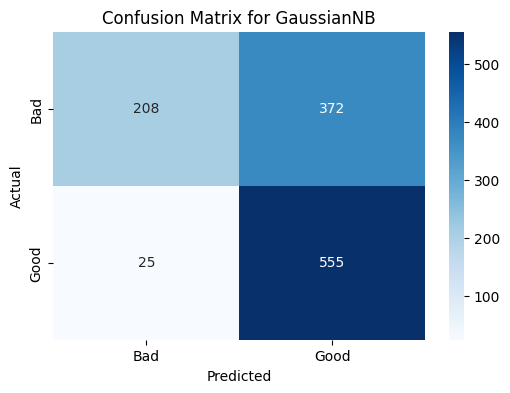

 70%|███████   | 7/10 [00:04<00:01,  1.96it/s]

Classification Report for GaussianNB:

              precision    recall  f1-score   support

         Bad       0.89      0.36      0.51       580
        Good       0.60      0.96      0.74       580

    accuracy                           0.66      1160
   macro avg       0.75      0.66      0.62      1160
weighted avg       0.75      0.66      0.62      1160

Saved XGBClassifier to /kaggle/working/Classification models/XGBClassifier.pkl


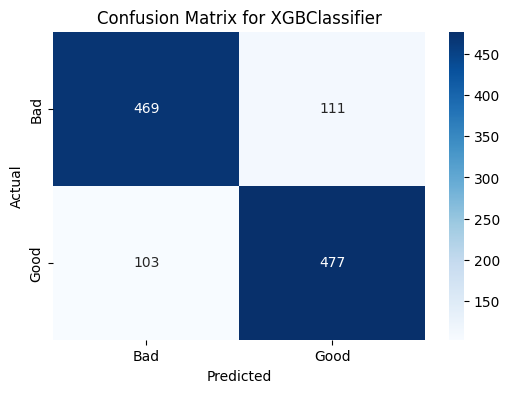

 80%|████████  | 8/10 [00:04<00:00,  2.15it/s]

Classification Report for XGBClassifier:

              precision    recall  f1-score   support

         Bad       0.82      0.81      0.81       580
        Good       0.81      0.82      0.82       580

    accuracy                           0.82      1160
   macro avg       0.82      0.82      0.82      1160
weighted avg       0.82      0.82      0.82      1160

Saved AdaBoostClassifier to /kaggle/working/Classification models/AdaBoostClassifier.pkl


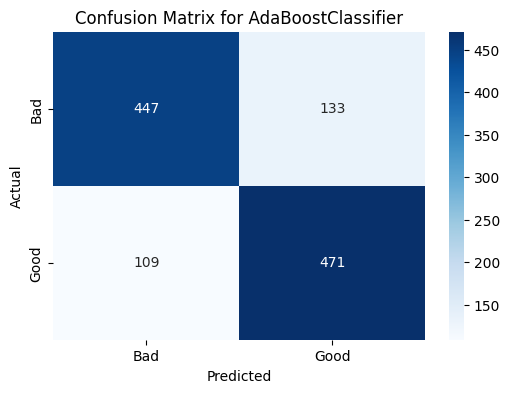

 90%|█████████ | 9/10 [00:05<00:00,  2.12it/s]

Classification Report for AdaBoostClassifier:

              precision    recall  f1-score   support

         Bad       0.80      0.77      0.79       580
        Good       0.78      0.81      0.80       580

    accuracy                           0.79      1160
   macro avg       0.79      0.79      0.79      1160
weighted avg       0.79      0.79      0.79      1160

Saved ExtraTreesClassifier to /kaggle/working/Classification models/ExtraTreesClassifier.pkl


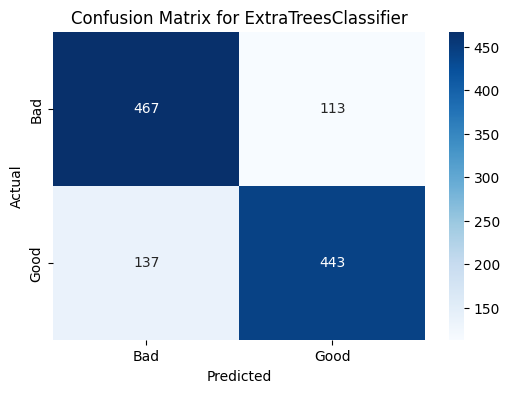

100%|██████████| 10/10 [00:05<00:00,  1.73it/s]

Classification Report for ExtraTreesClassifier:

              precision    recall  f1-score   support

         Bad       0.77      0.81      0.79       580
        Good       0.80      0.76      0.78       580

    accuracy                           0.78      1160
   macro avg       0.78      0.78      0.78      1160
weighted avg       0.78      0.78      0.78      1160



In [46]:
train_and_evaluate_models(X, y, models, model_save_dir)

# Evaluate all saved models on unseen data

## entire train and validation data

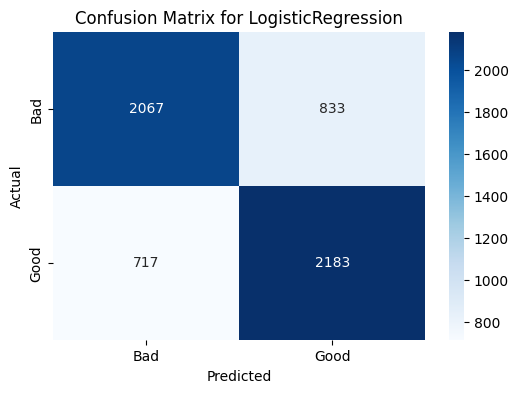

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.74      0.71      0.73      2900
        Good       0.72      0.75      0.74      2900

    accuracy                           0.73      5800
   macro avg       0.73      0.73      0.73      5800
weighted avg       0.73      0.73      0.73      5800



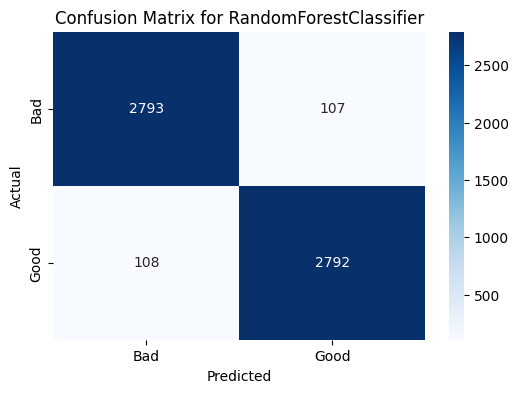

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.96      0.96      0.96      2900
        Good       0.96      0.96      0.96      2900

    accuracy                           0.96      5800
   macro avg       0.96      0.96      0.96      5800
weighted avg       0.96      0.96      0.96      5800



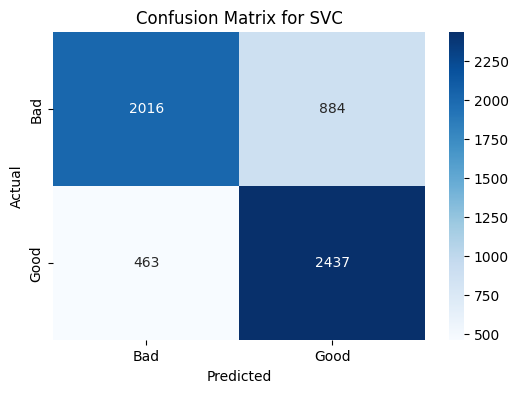

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.81      0.70      0.75      2900
        Good       0.73      0.84      0.78      2900

    accuracy                           0.77      5800
   macro avg       0.77      0.77      0.77      5800
weighted avg       0.77      0.77      0.77      5800



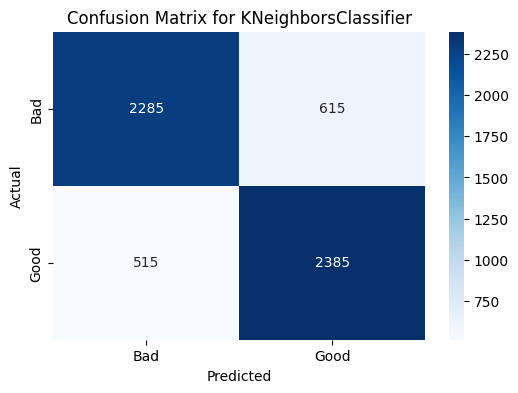

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.82      0.79      0.80      2900
        Good       0.80      0.82      0.81      2900

    accuracy                           0.81      5800
   macro avg       0.81      0.81      0.81      5800
weighted avg       0.81      0.81      0.81      5800



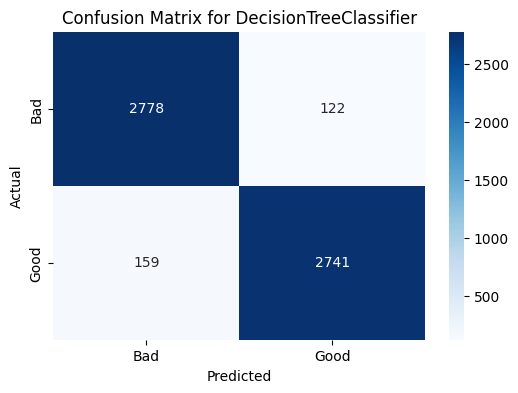

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.95      0.96      0.95      2900
        Good       0.96      0.95      0.95      2900

    accuracy                           0.95      5800
   macro avg       0.95      0.95      0.95      5800
weighted avg       0.95      0.95      0.95      5800



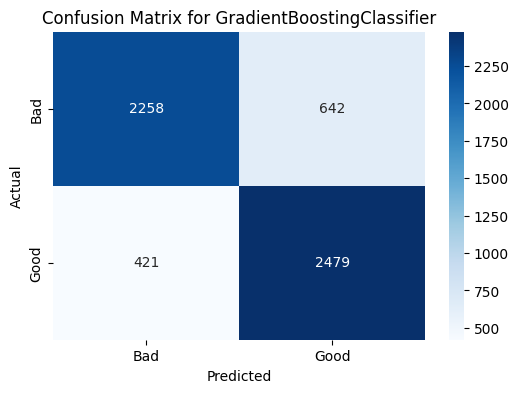

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.84      0.78      0.81      2900
        Good       0.79      0.85      0.82      2900

    accuracy                           0.82      5800
   macro avg       0.82      0.82      0.82      5800
weighted avg       0.82      0.82      0.82      5800



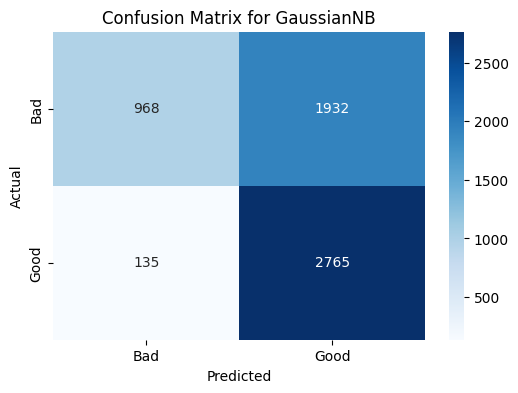

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.88      0.33      0.48      2900
        Good       0.59      0.95      0.73      2900

    accuracy                           0.64      5800
   macro avg       0.73      0.64      0.61      5800
weighted avg       0.73      0.64      0.61      5800



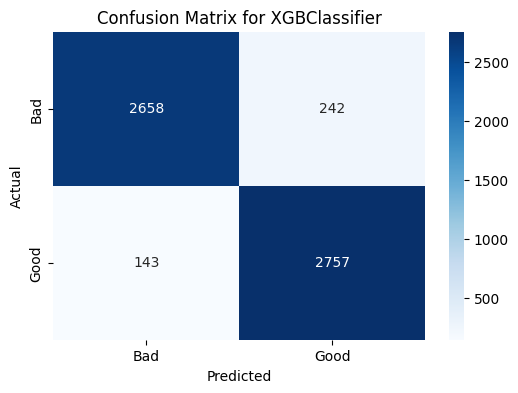

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.95      0.92      0.93      2900
        Good       0.92      0.95      0.93      2900

    accuracy                           0.93      5800
   macro avg       0.93      0.93      0.93      5800
weighted avg       0.93      0.93      0.93      5800



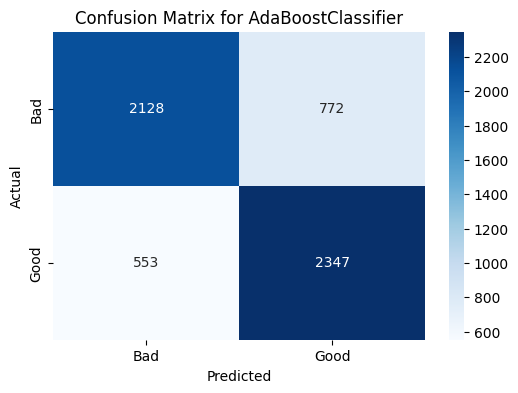

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.79      0.73      0.76      2900
        Good       0.75      0.81      0.78      2900

    accuracy                           0.77      5800
   macro avg       0.77      0.77      0.77      5800
weighted avg       0.77      0.77      0.77      5800



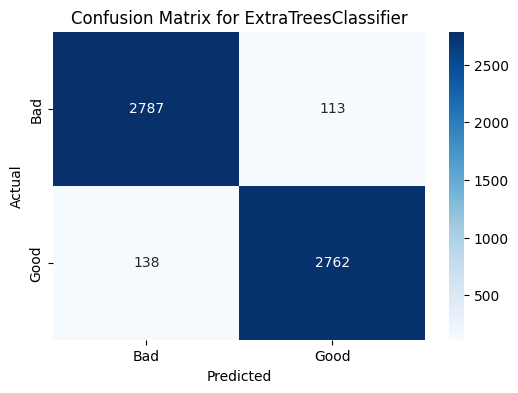

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.95      0.96      0.96      2900
        Good       0.96      0.95      0.96      2900

    accuracy                           0.96      5800
   macro avg       0.96      0.96      0.96      5800
weighted avg       0.96      0.96      0.96      5800



In [47]:
load_and_evaluate_models(X, y, model_save_dir, model_names, scaler_path=scaler_path)

## unseen data

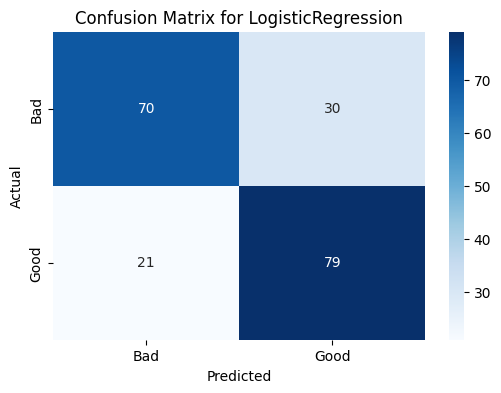

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.77      0.70      0.73       100
        Good       0.72      0.79      0.76       100

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



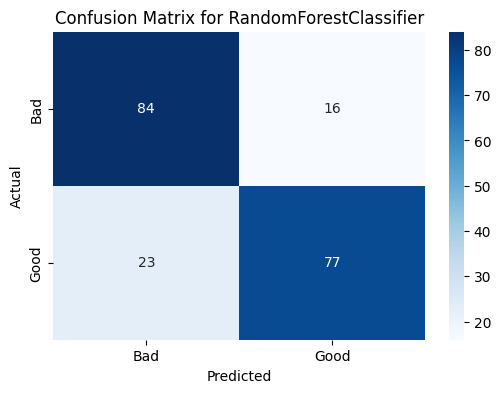

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.79      0.84      0.81       100
        Good       0.83      0.77      0.80       100

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.81      0.81      0.80       200



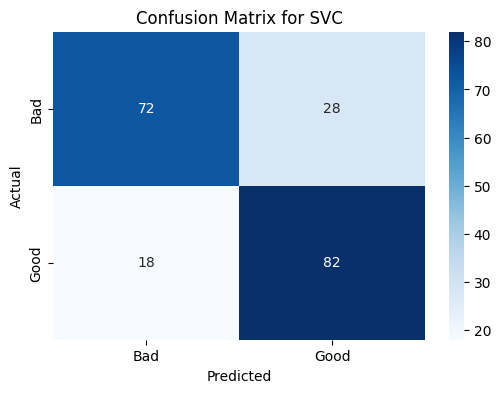

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.80      0.72      0.76       100
        Good       0.75      0.82      0.78       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



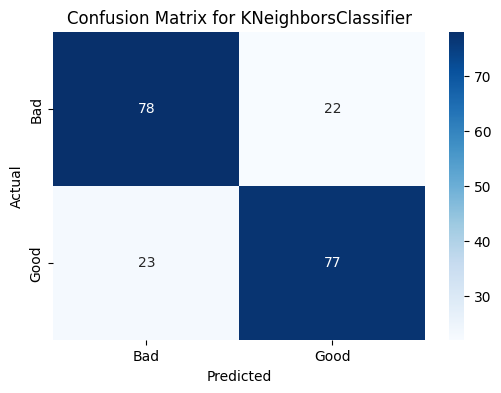

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.77      0.78      0.78       100
        Good       0.78      0.77      0.77       100

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200



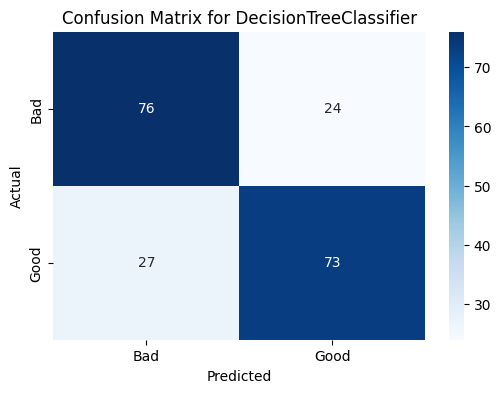

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.74      0.76      0.75       100
        Good       0.75      0.73      0.74       100

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



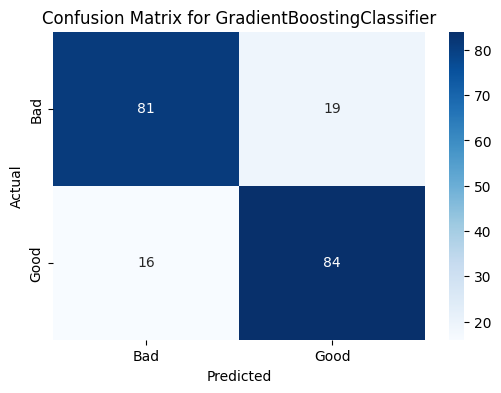

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.84      0.81      0.82       100
        Good       0.82      0.84      0.83       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



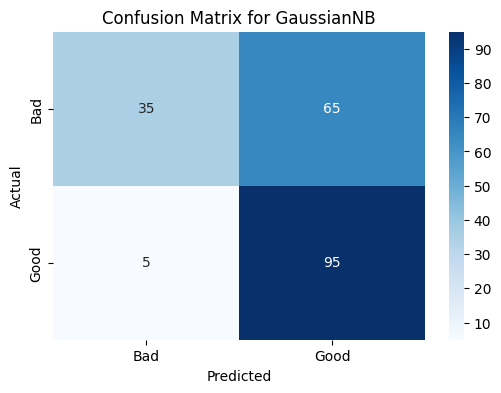

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.88      0.35      0.50       100
        Good       0.59      0.95      0.73       100

    accuracy                           0.65       200
   macro avg       0.73      0.65      0.62       200
weighted avg       0.73      0.65      0.62       200



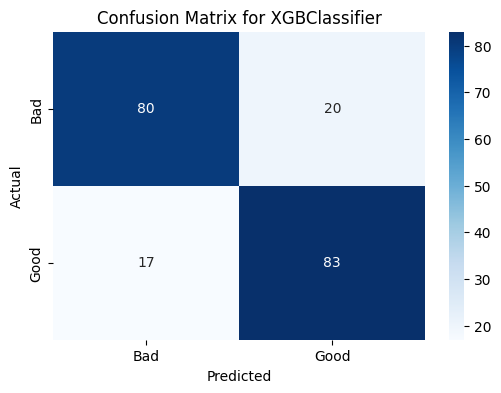

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.82      0.80      0.81       100
        Good       0.81      0.83      0.82       100

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



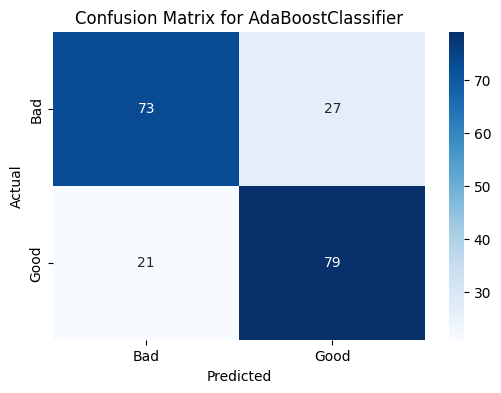

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.78      0.73      0.75       100
        Good       0.75      0.79      0.77       100

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200



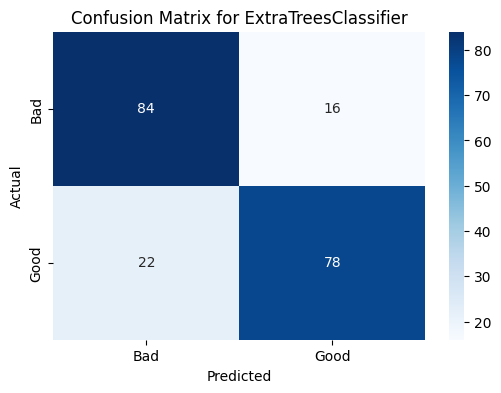

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.79      0.84      0.82       100
        Good       0.83      0.78      0.80       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



In [48]:
load_and_evaluate_models(unseen_X, unseen_y, model_save_dir, model_names, scaler_path=scaler_path)

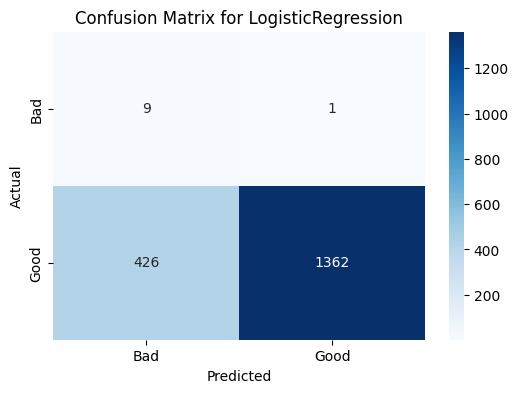

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.02      0.90      0.04        10
        Good       1.00      0.76      0.86      1788

    accuracy                           0.76      1798
   macro avg       0.51      0.83      0.45      1798
weighted avg       0.99      0.76      0.86      1798



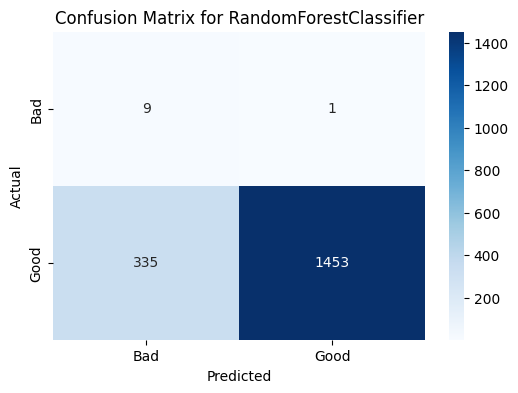

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.03      0.90      0.05        10
        Good       1.00      0.81      0.90      1788

    accuracy                           0.81      1798
   macro avg       0.51      0.86      0.47      1798
weighted avg       0.99      0.81      0.89      1798



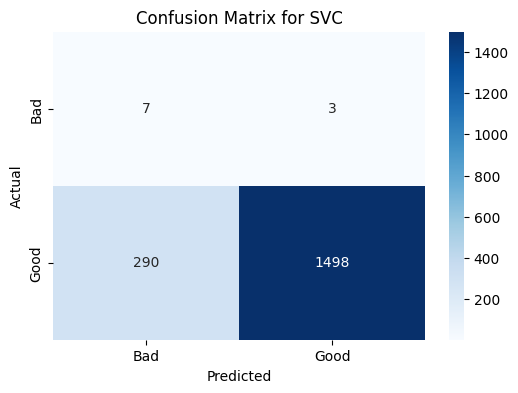

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.02      0.70      0.05        10
        Good       1.00      0.84      0.91      1788

    accuracy                           0.84      1798
   macro avg       0.51      0.77      0.48      1798
weighted avg       0.99      0.84      0.91      1798



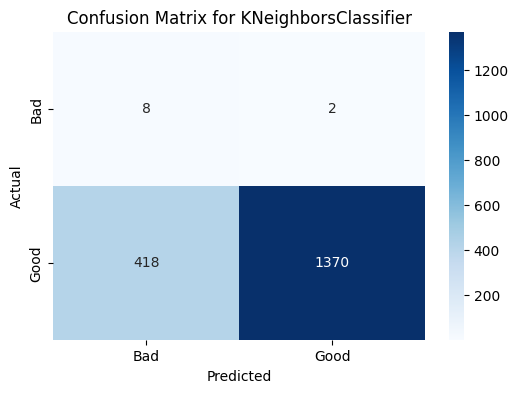

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.02      0.80      0.04        10
        Good       1.00      0.77      0.87      1788

    accuracy                           0.77      1798
   macro avg       0.51      0.78      0.45      1798
weighted avg       0.99      0.77      0.86      1798



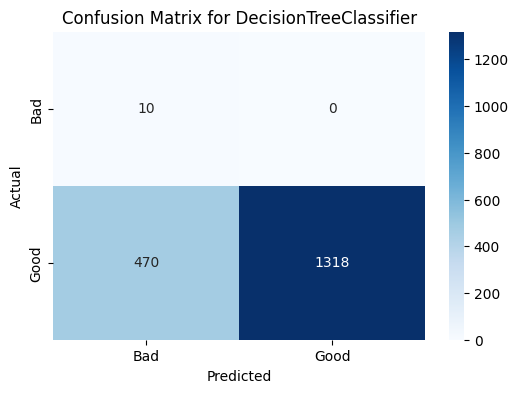

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.02      1.00      0.04        10
        Good       1.00      0.74      0.85      1788

    accuracy                           0.74      1798
   macro avg       0.51      0.87      0.44      1798
weighted avg       0.99      0.74      0.84      1798



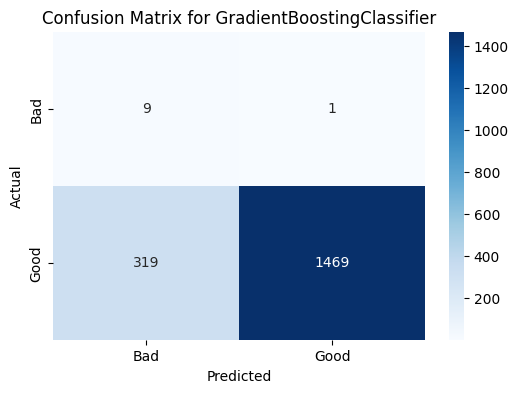

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.03      0.90      0.05        10
        Good       1.00      0.82      0.90      1788

    accuracy                           0.82      1798
   macro avg       0.51      0.86      0.48      1798
weighted avg       0.99      0.82      0.90      1798



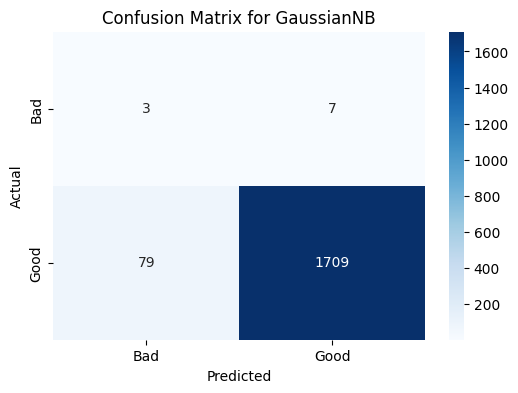

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.04      0.30      0.07        10
        Good       1.00      0.96      0.98      1788

    accuracy                           0.95      1798
   macro avg       0.52      0.63      0.52      1798
weighted avg       0.99      0.95      0.97      1798



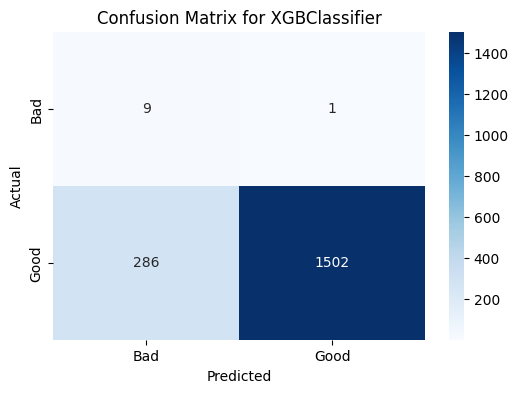

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.03      0.90      0.06        10
        Good       1.00      0.84      0.91      1788

    accuracy                           0.84      1798
   macro avg       0.51      0.87      0.49      1798
weighted avg       0.99      0.84      0.91      1798



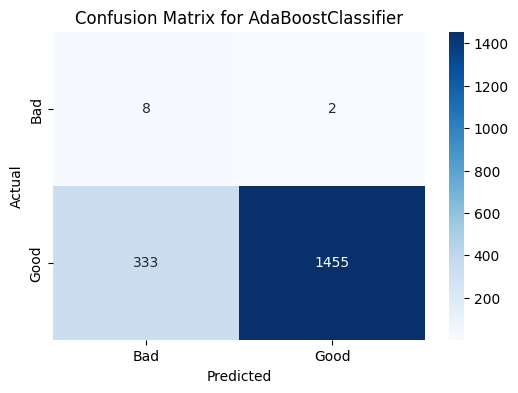

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.02      0.80      0.05        10
        Good       1.00      0.81      0.90      1788

    accuracy                           0.81      1798
   macro avg       0.51      0.81      0.47      1798
weighted avg       0.99      0.81      0.89      1798



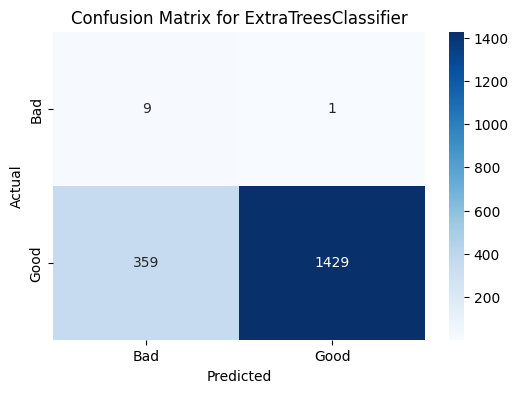

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.02      0.90      0.05        10
        Good       1.00      0.80      0.89      1788

    accuracy                           0.80      1798
   macro avg       0.51      0.85      0.47      1798
weighted avg       0.99      0.80      0.88      1798



In [49]:
load_and_evaluate_models(unseen_X_2, unseen_y_2, model_save_dir, model_names, scaler_path=scaler_path)

## dec data collection

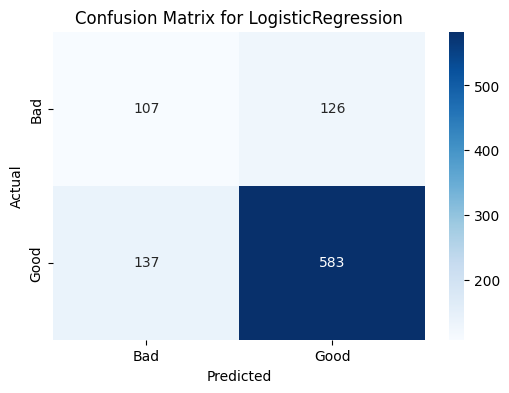

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.44      0.46      0.45       233
        Good       0.82      0.81      0.82       720

    accuracy                           0.72       953
   macro avg       0.63      0.63      0.63       953
weighted avg       0.73      0.72      0.73       953



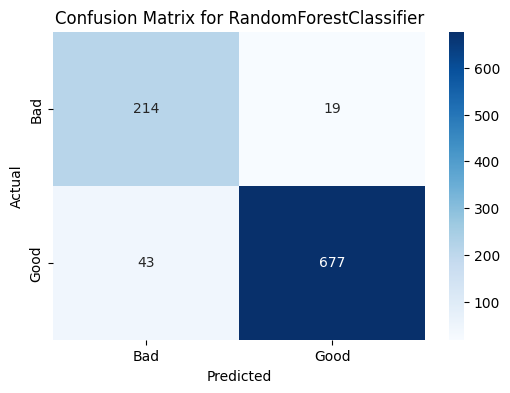

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.83      0.92      0.87       233
        Good       0.97      0.94      0.96       720

    accuracy                           0.93       953
   macro avg       0.90      0.93      0.91       953
weighted avg       0.94      0.93      0.94       953



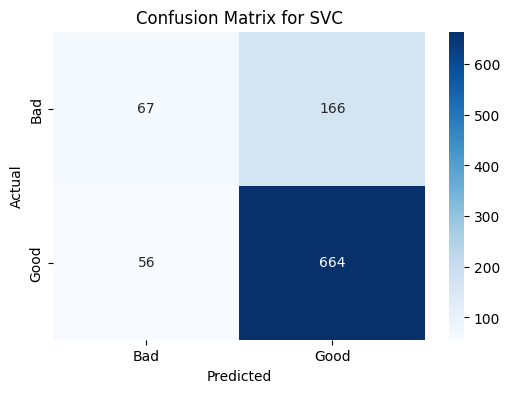

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.54      0.29      0.38       233
        Good       0.80      0.92      0.86       720

    accuracy                           0.77       953
   macro avg       0.67      0.60      0.62       953
weighted avg       0.74      0.77      0.74       953



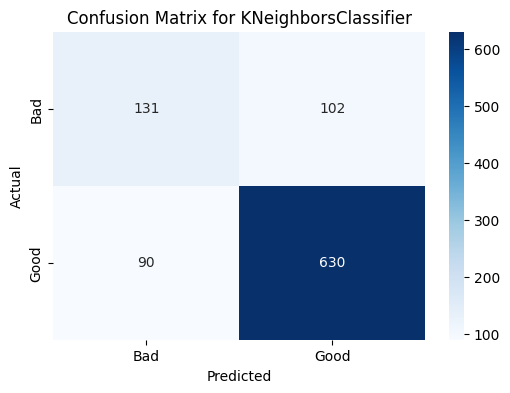

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.59      0.56      0.58       233
        Good       0.86      0.88      0.87       720

    accuracy                           0.80       953
   macro avg       0.73      0.72      0.72       953
weighted avg       0.80      0.80      0.80       953



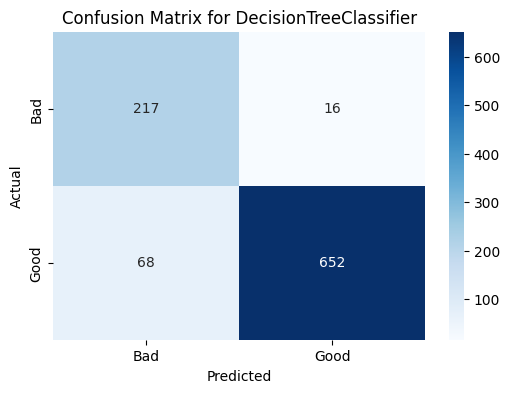

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.76      0.93      0.84       233
        Good       0.98      0.91      0.94       720

    accuracy                           0.91       953
   macro avg       0.87      0.92      0.89       953
weighted avg       0.92      0.91      0.91       953



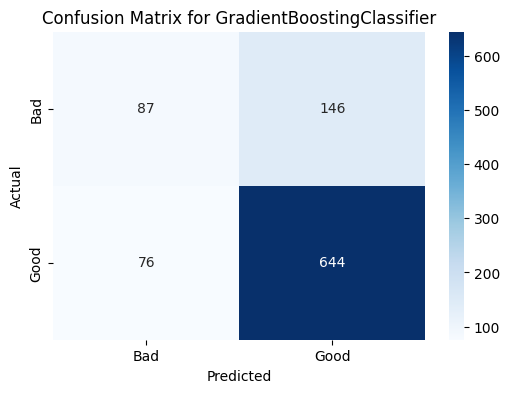

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.53      0.37      0.44       233
        Good       0.82      0.89      0.85       720

    accuracy                           0.77       953
   macro avg       0.67      0.63      0.65       953
weighted avg       0.75      0.77      0.75       953



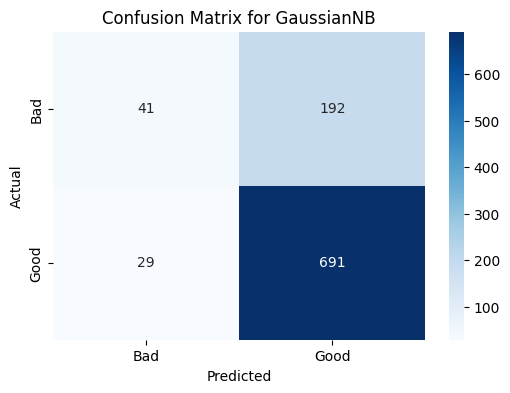

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.59      0.18      0.27       233
        Good       0.78      0.96      0.86       720

    accuracy                           0.77       953
   macro avg       0.68      0.57      0.57       953
weighted avg       0.73      0.77      0.72       953



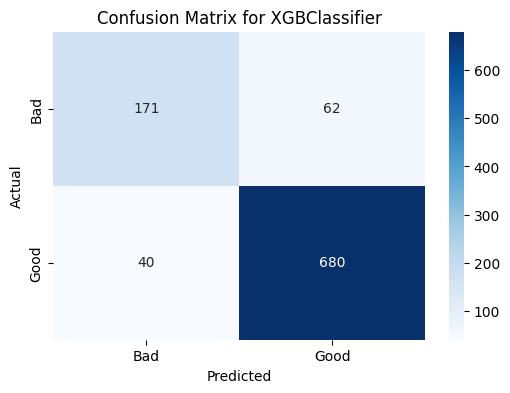

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.81      0.73      0.77       233
        Good       0.92      0.94      0.93       720

    accuracy                           0.89       953
   macro avg       0.86      0.84      0.85       953
weighted avg       0.89      0.89      0.89       953



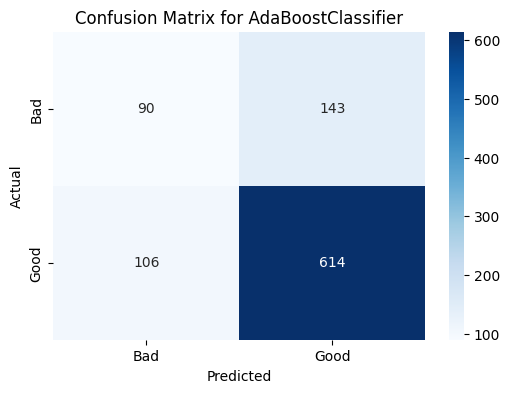

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.46      0.39      0.42       233
        Good       0.81      0.85      0.83       720

    accuracy                           0.74       953
   macro avg       0.64      0.62      0.63       953
weighted avg       0.73      0.74      0.73       953



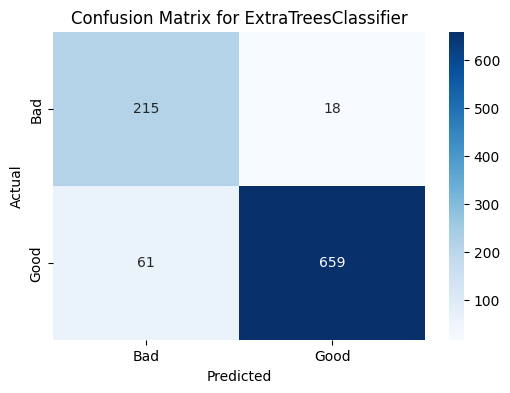

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.78      0.92      0.84       233
        Good       0.97      0.92      0.94       720

    accuracy                           0.92       953
   macro avg       0.88      0.92      0.89       953
weighted avg       0.93      0.92      0.92       953



In [50]:
unseen_X_dec, unseen_y_dec = prepare_data(good_dec, bad_dec)
load_and_evaluate_models(unseen_X_dec, unseen_y_dec, model_save_dir, model_names, scaler_path=scaler_path)

## app testing data till dec-22-2024

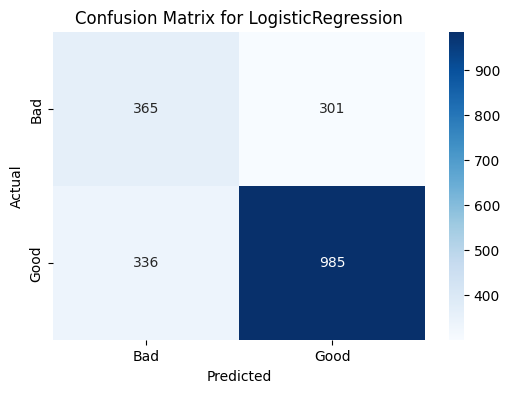

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.52      0.55      0.53       666
        Good       0.77      0.75      0.76      1321

    accuracy                           0.68      1987
   macro avg       0.64      0.65      0.64      1987
weighted avg       0.68      0.68      0.68      1987



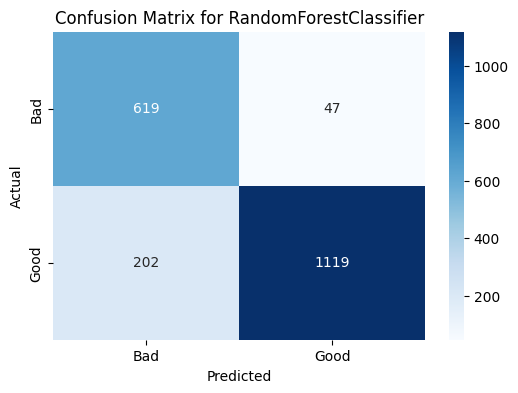

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.75      0.93      0.83       666
        Good       0.96      0.85      0.90      1321

    accuracy                           0.87      1987
   macro avg       0.86      0.89      0.87      1987
weighted avg       0.89      0.87      0.88      1987



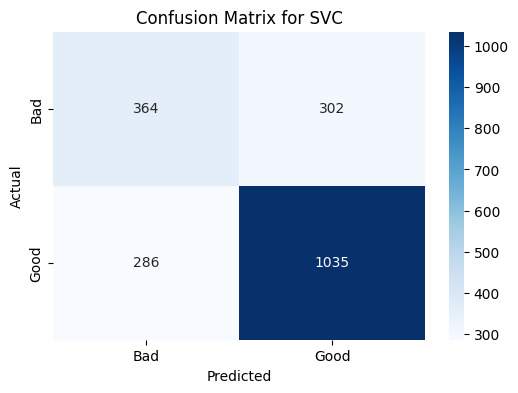

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.56      0.55      0.55       666
        Good       0.77      0.78      0.78      1321

    accuracy                           0.70      1987
   macro avg       0.67      0.67      0.67      1987
weighted avg       0.70      0.70      0.70      1987



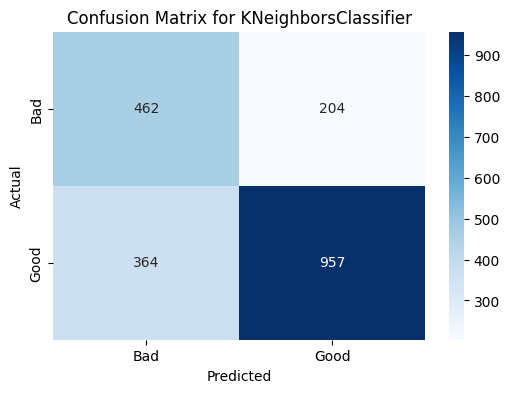

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.56      0.69      0.62       666
        Good       0.82      0.72      0.77      1321

    accuracy                           0.71      1987
   macro avg       0.69      0.71      0.70      1987
weighted avg       0.74      0.71      0.72      1987



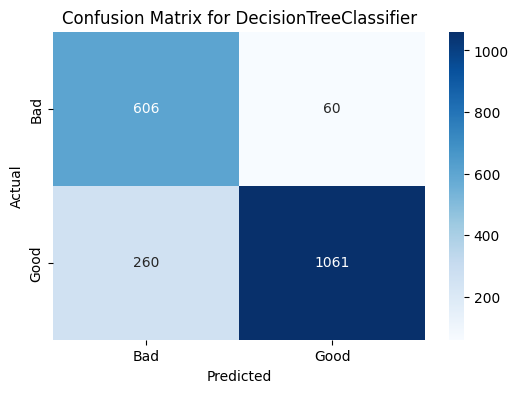

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.70      0.91      0.79       666
        Good       0.95      0.80      0.87      1321

    accuracy                           0.84      1987
   macro avg       0.82      0.86      0.83      1987
weighted avg       0.86      0.84      0.84      1987



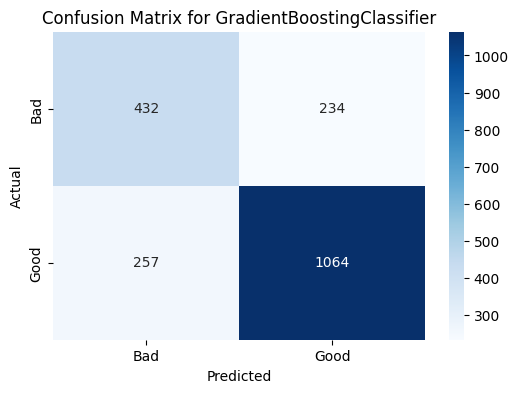

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.63      0.65      0.64       666
        Good       0.82      0.81      0.81      1321

    accuracy                           0.75      1987
   macro avg       0.72      0.73      0.73      1987
weighted avg       0.76      0.75      0.75      1987



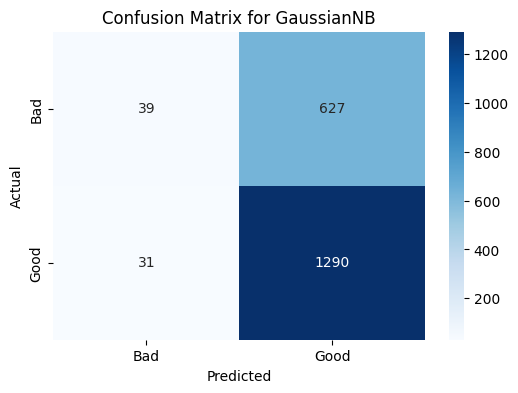

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.56      0.06      0.11       666
        Good       0.67      0.98      0.80      1321

    accuracy                           0.67      1987
   macro avg       0.62      0.52      0.45      1987
weighted avg       0.63      0.67      0.57      1987



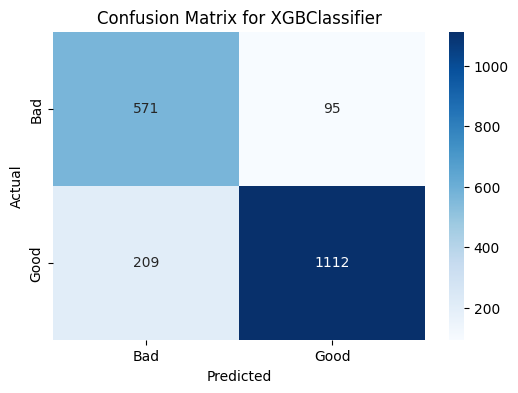

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.73      0.86      0.79       666
        Good       0.92      0.84      0.88      1321

    accuracy                           0.85      1987
   macro avg       0.83      0.85      0.83      1987
weighted avg       0.86      0.85      0.85      1987



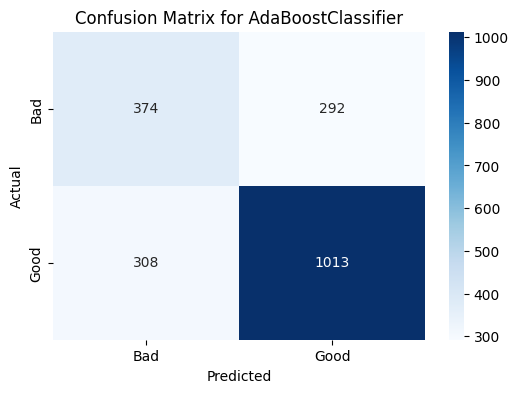

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.55      0.56      0.55       666
        Good       0.78      0.77      0.77      1321

    accuracy                           0.70      1987
   macro avg       0.66      0.66      0.66      1987
weighted avg       0.70      0.70      0.70      1987



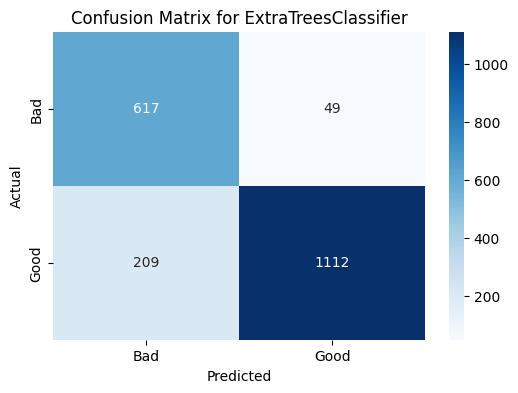

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.75      0.93      0.83       666
        Good       0.96      0.84      0.90      1321

    accuracy                           0.87      1987
   macro avg       0.85      0.88      0.86      1987
weighted avg       0.89      0.87      0.87      1987



In [51]:
unseen_X_app, unseen_y_app = prepare_data(good_app, bad_app)
load_and_evaluate_models(unseen_X_app, unseen_y_app, model_save_dir, model_names, scaler_path=scaler_path)

## app testing data till aug-13-2024

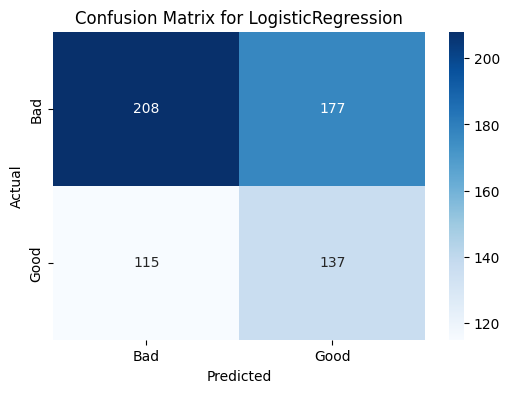

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.64      0.54      0.59       385
        Good       0.44      0.54      0.48       252

    accuracy                           0.54       637
   macro avg       0.54      0.54      0.54       637
weighted avg       0.56      0.54      0.55       637



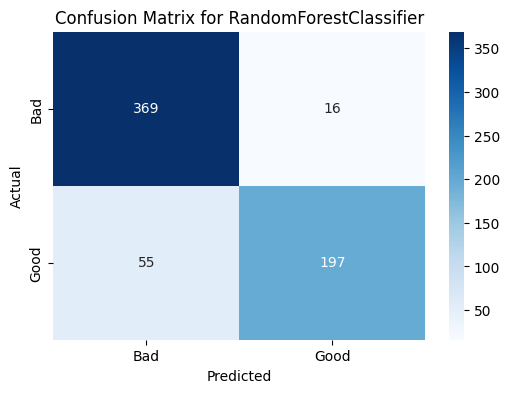

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.87      0.96      0.91       385
        Good       0.92      0.78      0.85       252

    accuracy                           0.89       637
   macro avg       0.90      0.87      0.88       637
weighted avg       0.89      0.89      0.89       637



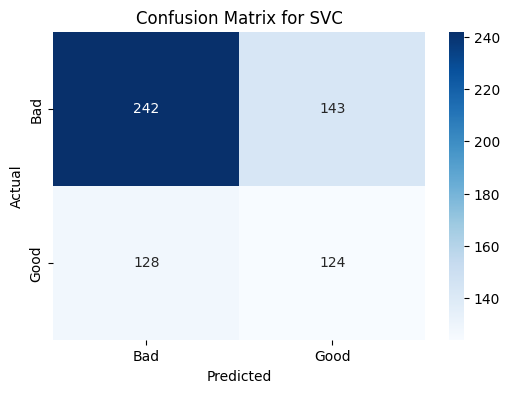

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.65      0.63      0.64       385
        Good       0.46      0.49      0.48       252

    accuracy                           0.57       637
   macro avg       0.56      0.56      0.56       637
weighted avg       0.58      0.57      0.58       637



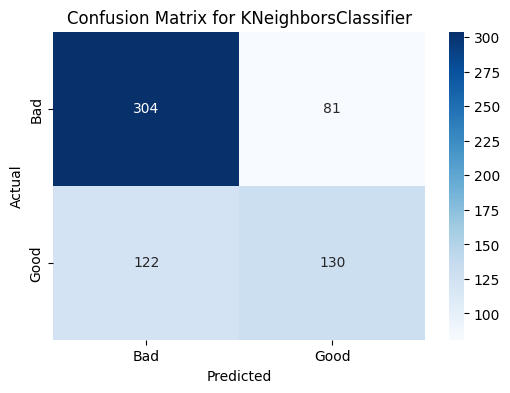

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.71      0.79      0.75       385
        Good       0.62      0.52      0.56       252

    accuracy                           0.68       637
   macro avg       0.66      0.65      0.66       637
weighted avg       0.68      0.68      0.68       637



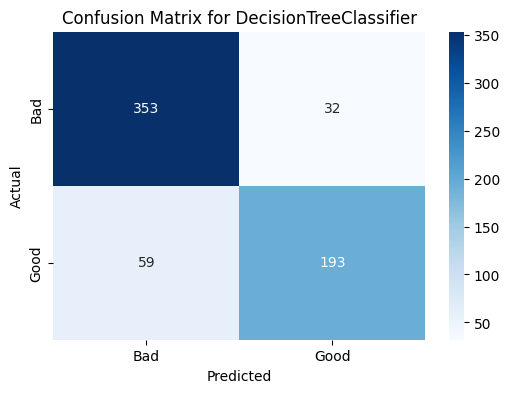

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.86      0.92      0.89       385
        Good       0.86      0.77      0.81       252

    accuracy                           0.86       637
   macro avg       0.86      0.84      0.85       637
weighted avg       0.86      0.86      0.86       637



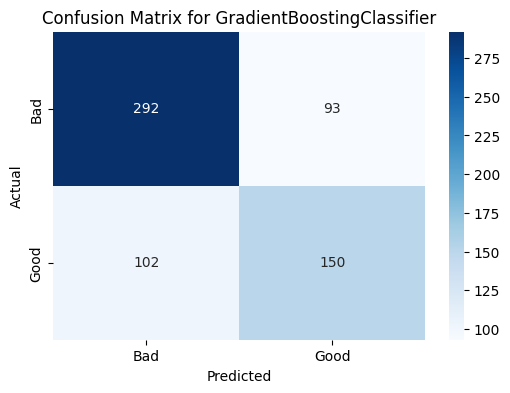

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.74      0.76      0.75       385
        Good       0.62      0.60      0.61       252

    accuracy                           0.69       637
   macro avg       0.68      0.68      0.68       637
weighted avg       0.69      0.69      0.69       637



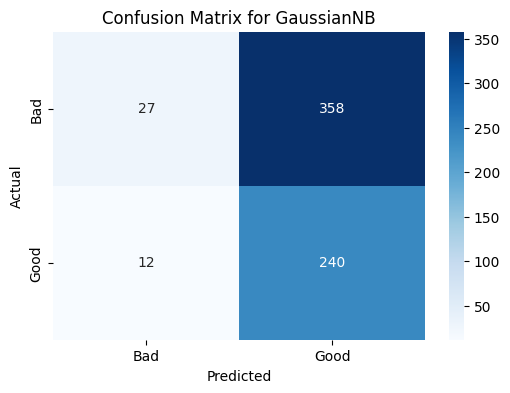

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.69      0.07      0.13       385
        Good       0.40      0.95      0.56       252

    accuracy                           0.42       637
   macro avg       0.55      0.51      0.35       637
weighted avg       0.58      0.42      0.30       637



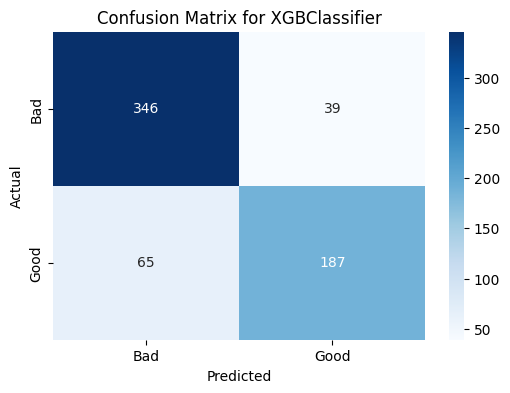

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.84      0.90      0.87       385
        Good       0.83      0.74      0.78       252

    accuracy                           0.84       637
   macro avg       0.83      0.82      0.83       637
weighted avg       0.84      0.84      0.83       637



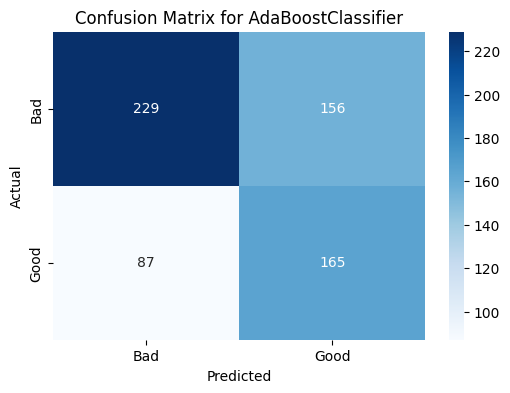

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.72      0.59      0.65       385
        Good       0.51      0.65      0.58       252

    accuracy                           0.62       637
   macro avg       0.62      0.62      0.61       637
weighted avg       0.64      0.62      0.62       637



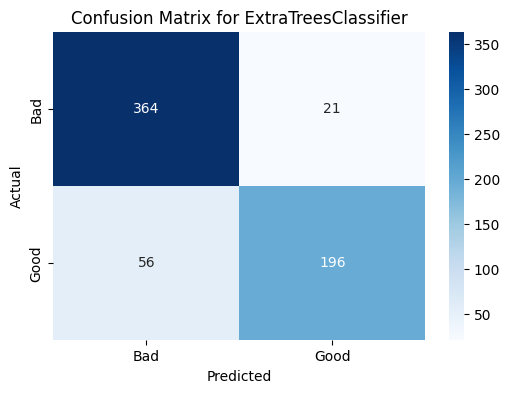

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.87      0.95      0.90       385
        Good       0.90      0.78      0.84       252

    accuracy                           0.88       637
   macro avg       0.88      0.86      0.87       637
weighted avg       0.88      0.88      0.88       637



In [52]:
unseen_X_old, unseen_y_old = prepare_data(good_app_old, bad_app_old)
load_and_evaluate_models(unseen_X_old, unseen_y_old, model_save_dir, model_names, scaler_path=scaler_path)

## app testing data from aug-13-2024

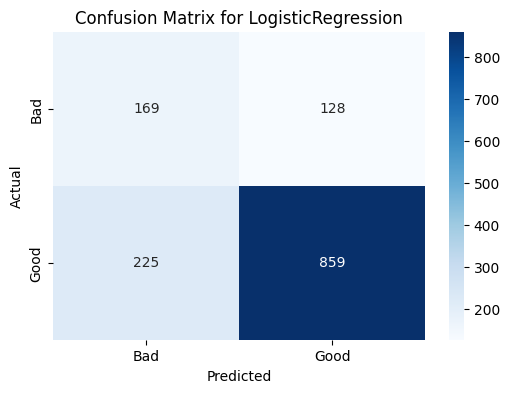

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.43      0.57      0.49       297
        Good       0.87      0.79      0.83      1084

    accuracy                           0.74      1381
   macro avg       0.65      0.68      0.66      1381
weighted avg       0.78      0.74      0.76      1381



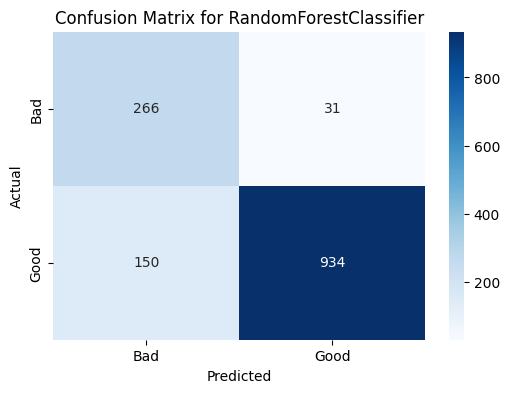

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.64      0.90      0.75       297
        Good       0.97      0.86      0.91      1084

    accuracy                           0.87      1381
   macro avg       0.80      0.88      0.83      1381
weighted avg       0.90      0.87      0.88      1381



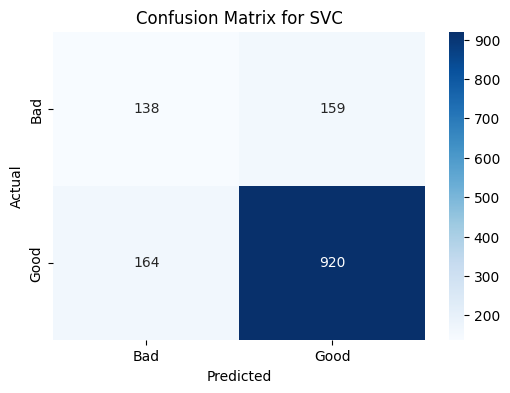

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.46      0.46      0.46       297
        Good       0.85      0.85      0.85      1084

    accuracy                           0.77      1381
   macro avg       0.65      0.66      0.66      1381
weighted avg       0.77      0.77      0.77      1381



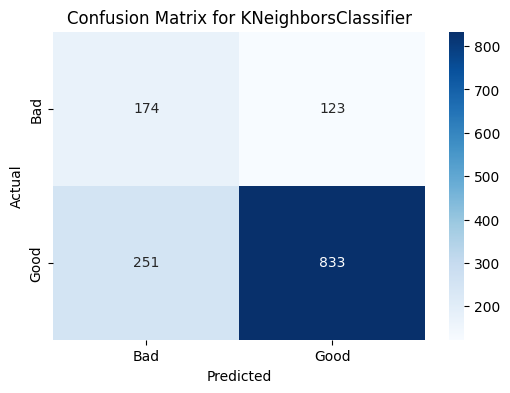

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.41      0.59      0.48       297
        Good       0.87      0.77      0.82      1084

    accuracy                           0.73      1381
   macro avg       0.64      0.68      0.65      1381
weighted avg       0.77      0.73      0.74      1381



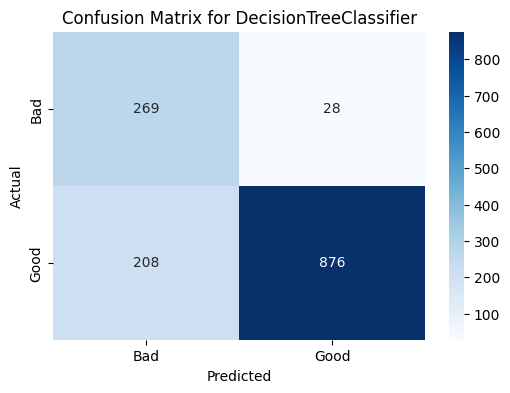

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.56      0.91      0.70       297
        Good       0.97      0.81      0.88      1084

    accuracy                           0.83      1381
   macro avg       0.77      0.86      0.79      1381
weighted avg       0.88      0.83      0.84      1381



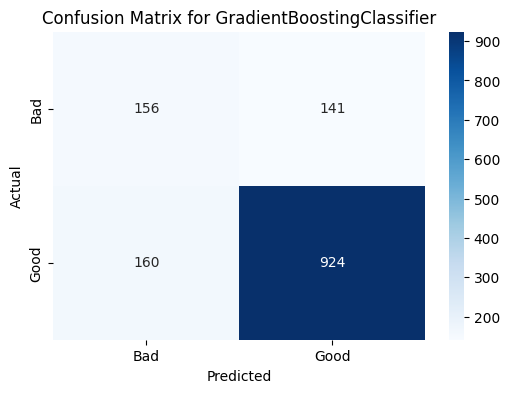

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.49      0.53      0.51       297
        Good       0.87      0.85      0.86      1084

    accuracy                           0.78      1381
   macro avg       0.68      0.69      0.68      1381
weighted avg       0.79      0.78      0.78      1381



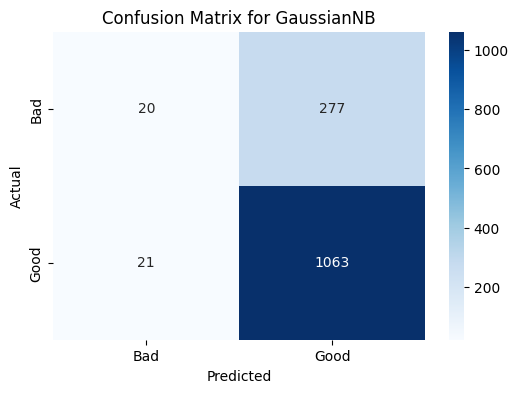

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.49      0.07      0.12       297
        Good       0.79      0.98      0.88      1084

    accuracy                           0.78      1381
   macro avg       0.64      0.52      0.50      1381
weighted avg       0.73      0.78      0.71      1381



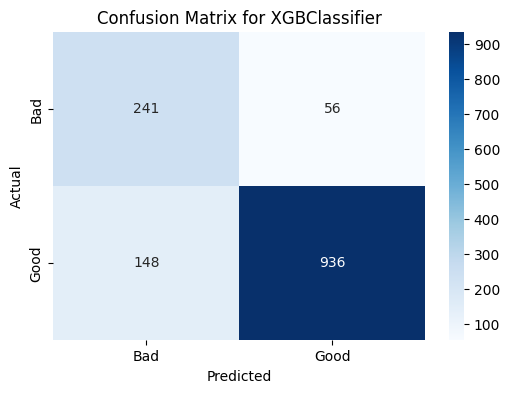

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.62      0.81      0.70       297
        Good       0.94      0.86      0.90      1084

    accuracy                           0.85      1381
   macro avg       0.78      0.84      0.80      1381
weighted avg       0.87      0.85      0.86      1381



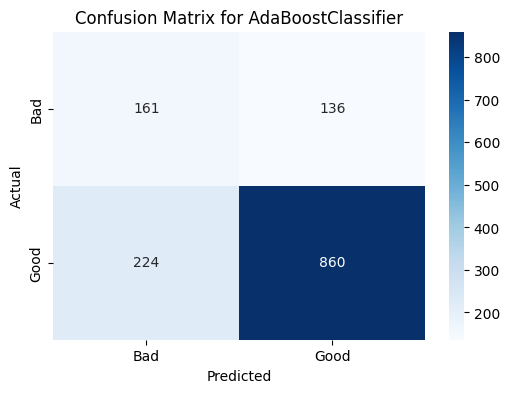

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.42      0.54      0.47       297
        Good       0.86      0.79      0.83      1084

    accuracy                           0.74      1381
   macro avg       0.64      0.67      0.65      1381
weighted avg       0.77      0.74      0.75      1381



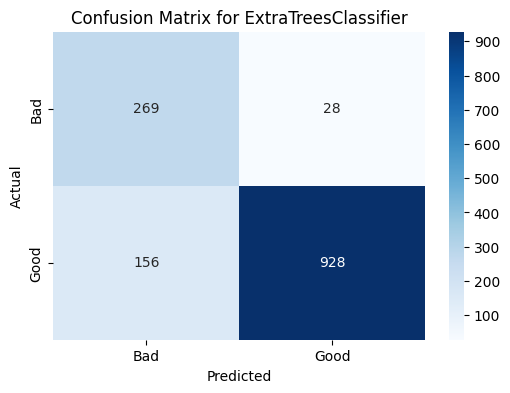

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.63      0.91      0.75       297
        Good       0.97      0.86      0.91      1084

    accuracy                           0.87      1381
   macro avg       0.80      0.88      0.83      1381
weighted avg       0.90      0.87      0.87      1381



In [53]:
unseen_X_new, unseen_y_new = prepare_data(good_app_new, bad_app_new)
load_and_evaluate_models(unseen_X_new, unseen_y_new, model_save_dir, model_names, scaler_path=scaler_path)

## only dec app testing data

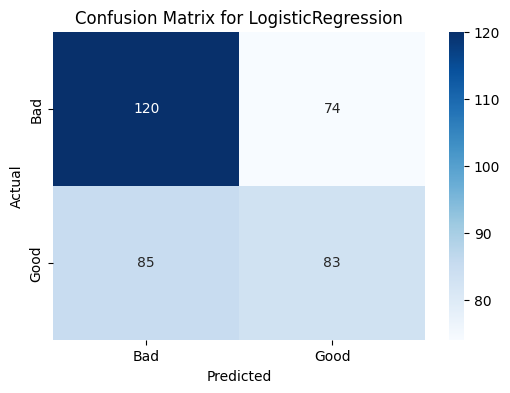

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.59      0.62      0.60       194
        Good       0.53      0.49      0.51       168

    accuracy                           0.56       362
   macro avg       0.56      0.56      0.56       362
weighted avg       0.56      0.56      0.56       362



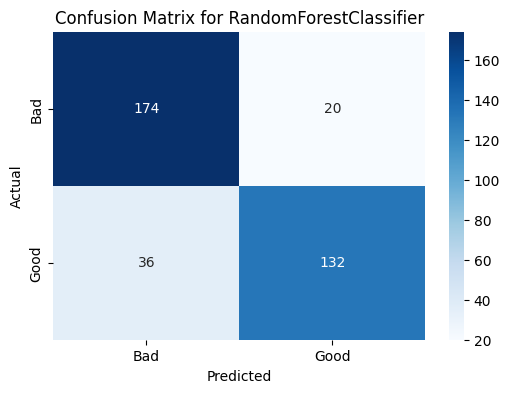

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.83      0.90      0.86       194
        Good       0.87      0.79      0.82       168

    accuracy                           0.85       362
   macro avg       0.85      0.84      0.84       362
weighted avg       0.85      0.85      0.84       362



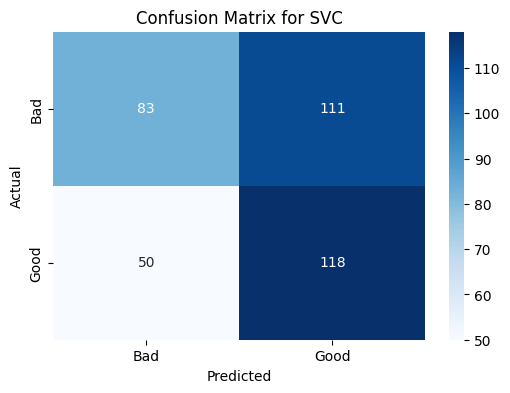

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.62      0.43      0.51       194
        Good       0.52      0.70      0.59       168

    accuracy                           0.56       362
   macro avg       0.57      0.57      0.55       362
weighted avg       0.57      0.56      0.55       362



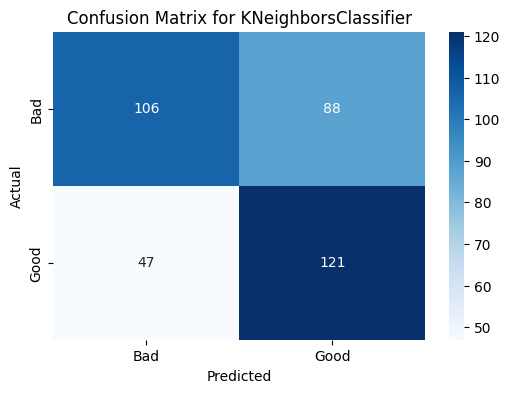

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.69      0.55      0.61       194
        Good       0.58      0.72      0.64       168

    accuracy                           0.63       362
   macro avg       0.64      0.63      0.63       362
weighted avg       0.64      0.63      0.63       362



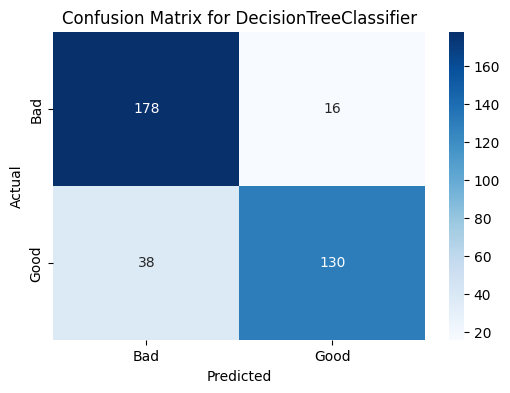

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.82      0.92      0.87       194
        Good       0.89      0.77      0.83       168

    accuracy                           0.85       362
   macro avg       0.86      0.85      0.85       362
weighted avg       0.85      0.85      0.85       362



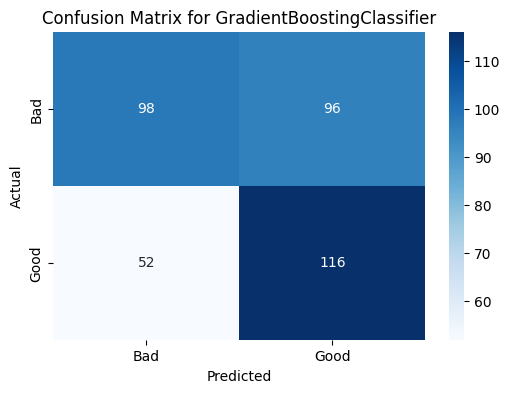

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.65      0.51      0.57       194
        Good       0.55      0.69      0.61       168

    accuracy                           0.59       362
   macro avg       0.60      0.60      0.59       362
weighted avg       0.60      0.59      0.59       362



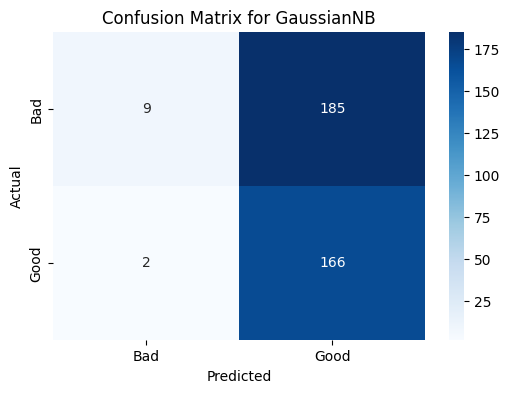

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.82      0.05      0.09       194
        Good       0.47      0.99      0.64       168

    accuracy                           0.48       362
   macro avg       0.65      0.52      0.36       362
weighted avg       0.66      0.48      0.34       362



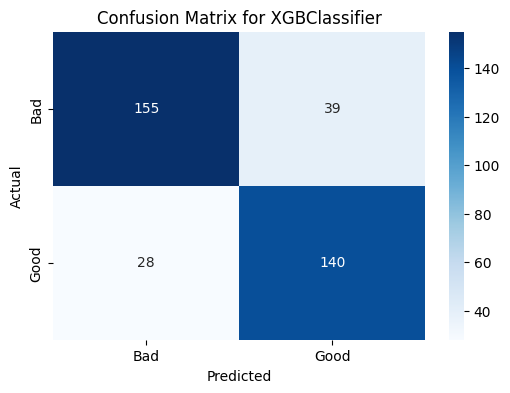

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.85      0.80      0.82       194
        Good       0.78      0.83      0.81       168

    accuracy                           0.81       362
   macro avg       0.81      0.82      0.81       362
weighted avg       0.82      0.81      0.82       362



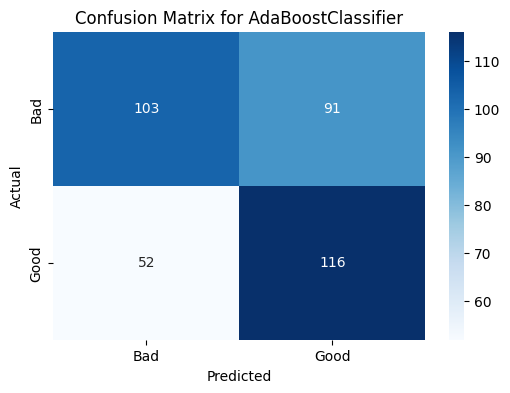

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.66      0.53      0.59       194
        Good       0.56      0.69      0.62       168

    accuracy                           0.60       362
   macro avg       0.61      0.61      0.60       362
weighted avg       0.62      0.60      0.60       362



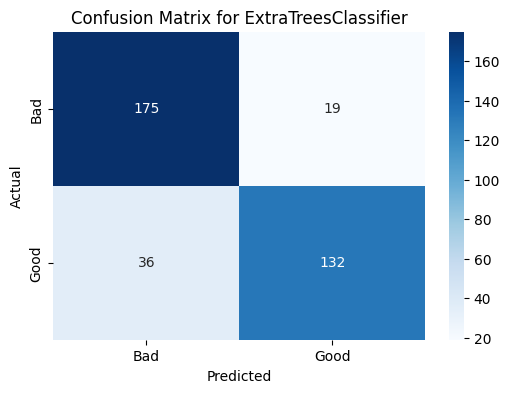

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.83      0.90      0.86       194
        Good       0.87      0.79      0.83       168

    accuracy                           0.85       362
   macro avg       0.85      0.84      0.85       362
weighted avg       0.85      0.85      0.85       362



In [54]:
unseen_X_new2, unseen_y_new2 = prepare_data(good_app_new2, bad_app_new2)
load_and_evaluate_models(unseen_X_new2, unseen_y_new2, model_save_dir, model_names, scaler_path=scaler_path)

In [55]:
d = {'2025-01-02': {'good':72, 'bad':13},
     '2024-12-24': {'good':54, 'bad':20},
     '2024-12-26': {'good':84, 'bad':50}}

In [58]:
good_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_good_app_data_dec20tojan7.csv')
bad_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_bad_app_data_dec20tojan7.csv')

def filter_df(df, date):
    df = df.copy()
    filenames = df['SegmentedFilename']
    df['dates'] = df['SegmentedFilename'].apply(lambda x: x[:10])
    df = df[df['dates']==date]
    df.drop(columns=['dates'], inplace=True)
    return df

# good_app_new3 = filter_df(good_app_new3, '2024-12-26')
# bad_app_new3 = filter_df(bad_app_new3, '2024-12-26')

good_app_new3 = filter_df(good_app_new3, '2025-01-02')
bad_app_new3 = filter_df(bad_app_new3, '2025-01-02')

good_app_new3.dropna(inplace=True)
bad_app_new3.dropna(inplace=True)

cols_to_drop = ['FishDetected', 'SegmentedFilename', 'ScaleDetected']
good_app_new3.drop(columns=cols_to_drop, inplace=True)
bad_app_new3.drop(columns=cols_to_drop, inplace=True)

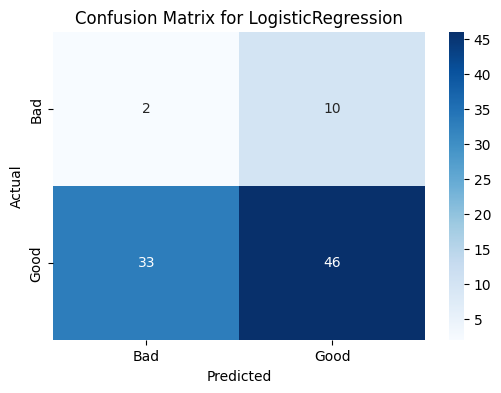

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.06      0.17      0.09        12
        Good       0.82      0.58      0.68        79

    accuracy                           0.53        91
   macro avg       0.44      0.37      0.38        91
weighted avg       0.72      0.53      0.60        91



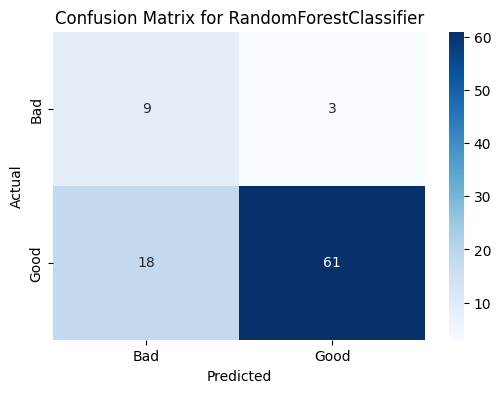

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.33      0.75      0.46        12
        Good       0.95      0.77      0.85        79

    accuracy                           0.77        91
   macro avg       0.64      0.76      0.66        91
weighted avg       0.87      0.77      0.80        91



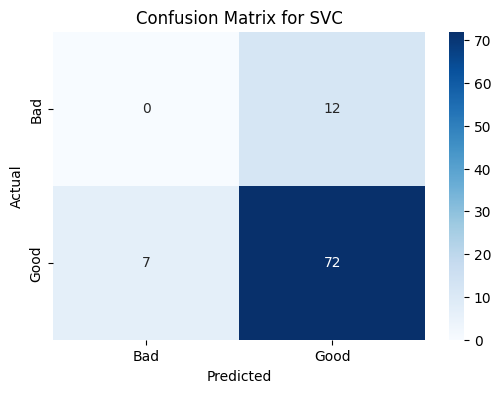

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00        12
        Good       0.86      0.91      0.88        79

    accuracy                           0.79        91
   macro avg       0.43      0.46      0.44        91
weighted avg       0.74      0.79      0.77        91



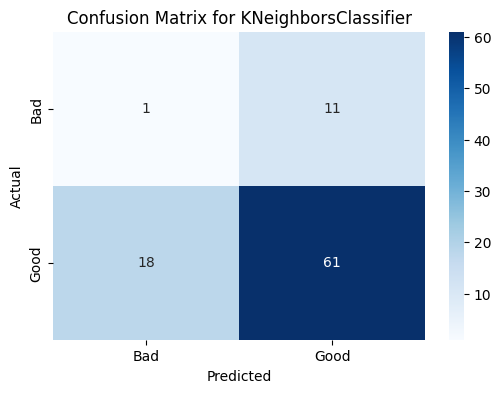

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.05      0.08      0.06        12
        Good       0.85      0.77      0.81        79

    accuracy                           0.68        91
   macro avg       0.45      0.43      0.44        91
weighted avg       0.74      0.68      0.71        91



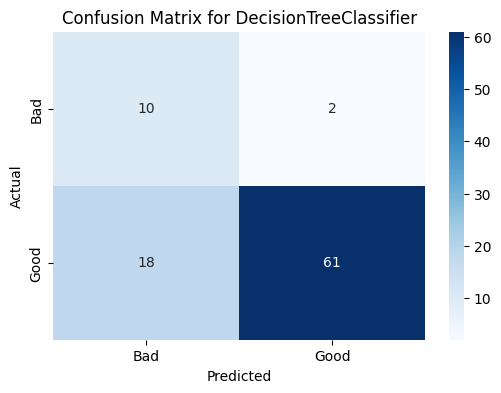

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.36      0.83      0.50        12
        Good       0.97      0.77      0.86        79

    accuracy                           0.78        91
   macro avg       0.66      0.80      0.68        91
weighted avg       0.89      0.78      0.81        91



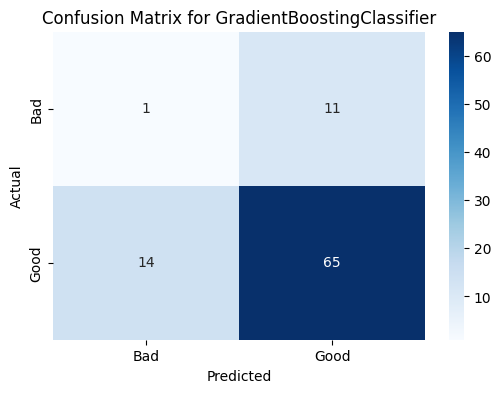

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.07      0.08      0.07        12
        Good       0.86      0.82      0.84        79

    accuracy                           0.73        91
   macro avg       0.46      0.45      0.46        91
weighted avg       0.75      0.73      0.74        91



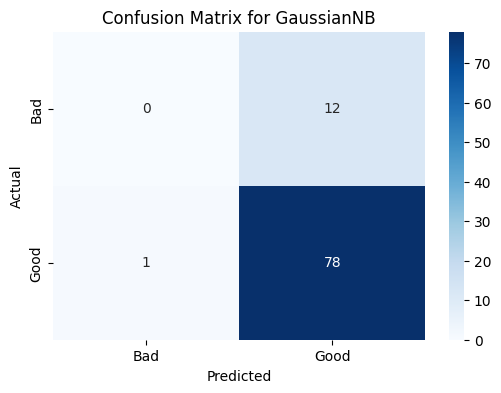

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00        12
        Good       0.87      0.99      0.92        79

    accuracy                           0.86        91
   macro avg       0.43      0.49      0.46        91
weighted avg       0.75      0.86      0.80        91



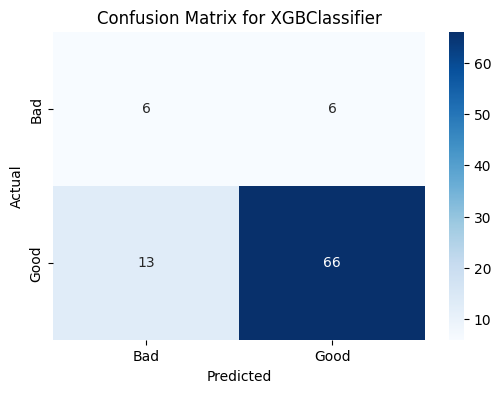

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.32      0.50      0.39        12
        Good       0.92      0.84      0.87        79

    accuracy                           0.79        91
   macro avg       0.62      0.67      0.63        91
weighted avg       0.84      0.79      0.81        91



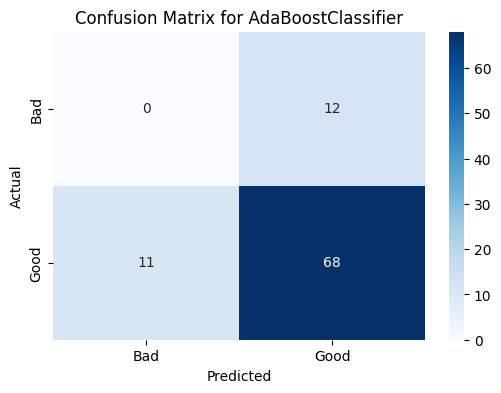

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00        12
        Good       0.85      0.86      0.86        79

    accuracy                           0.75        91
   macro avg       0.42      0.43      0.43        91
weighted avg       0.74      0.75      0.74        91



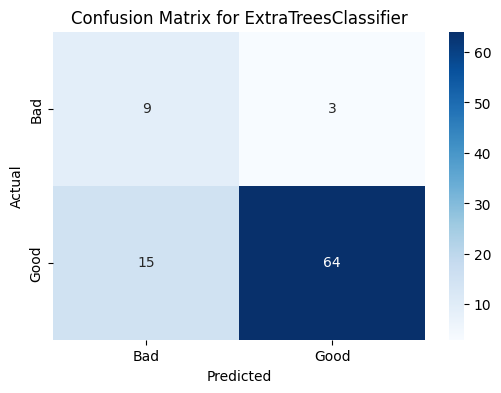

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.38      0.75      0.50        12
        Good       0.96      0.81      0.88        79

    accuracy                           0.80        91
   macro avg       0.67      0.78      0.69        91
weighted avg       0.88      0.80      0.83        91



In [59]:
unseen_X_new2, unseen_y_new2 = prepare_data(good_app_new3, bad_app_new3)
load_and_evaluate_models(unseen_X_new2, unseen_y_new2, model_save_dir, model_names, scaler_path=scaler_path)

In [60]:
good_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_good_app_data_dec20tojan7.csv')
bad_app_new3 = pd.read_csv('/kaggle/working/scale_based_size_bad_app_data_dec20tojan7.csv')

good_app_new3.dropna(inplace=True)
bad_app_new3.dropna(inplace=True)

cols_to_drop = ['FishDetected', 'SegmentedFilename', 'ScaleDetected']
good_app_new3.drop(columns=cols_to_drop, inplace=True)
bad_app_new3.drop(columns=cols_to_drop, inplace=True)

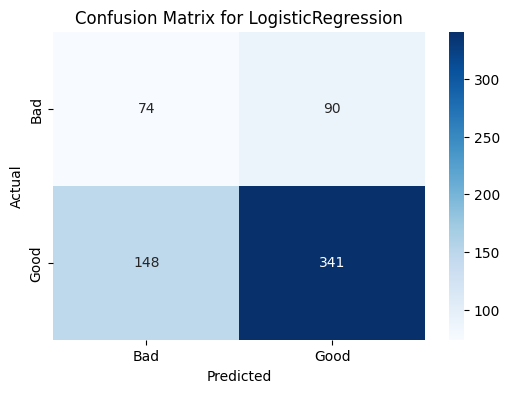

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.33      0.45      0.38       164
        Good       0.79      0.70      0.74       489

    accuracy                           0.64       653
   macro avg       0.56      0.57      0.56       653
weighted avg       0.68      0.64      0.65       653



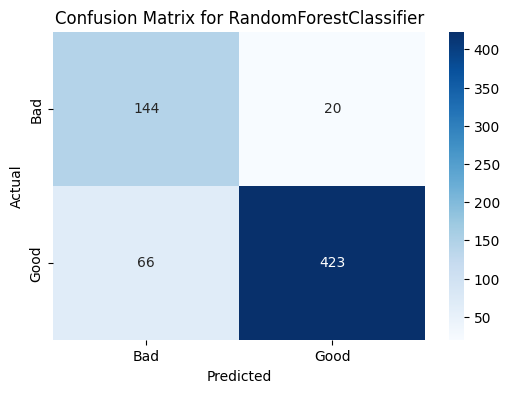

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.69      0.88      0.77       164
        Good       0.95      0.87      0.91       489

    accuracy                           0.87       653
   macro avg       0.82      0.87      0.84       653
weighted avg       0.89      0.87      0.87       653



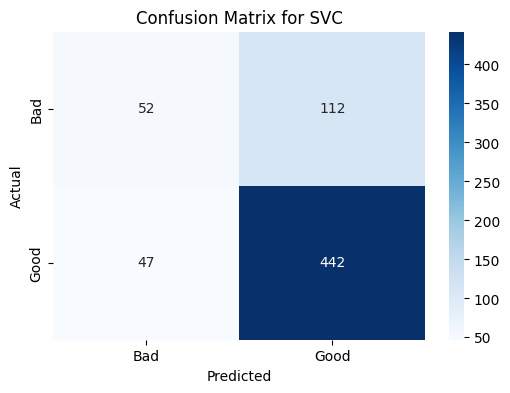

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.53      0.32      0.40       164
        Good       0.80      0.90      0.85       489

    accuracy                           0.76       653
   macro avg       0.66      0.61      0.62       653
weighted avg       0.73      0.76      0.73       653



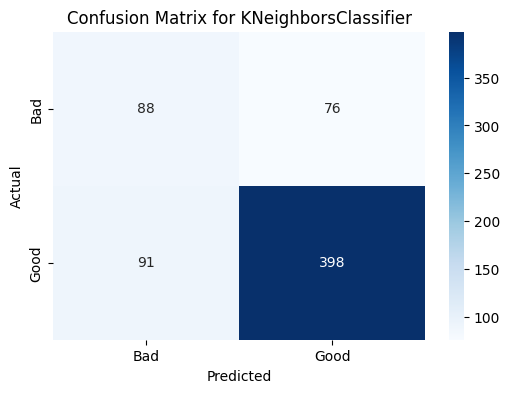

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.49      0.54      0.51       164
        Good       0.84      0.81      0.83       489

    accuracy                           0.74       653
   macro avg       0.67      0.68      0.67       653
weighted avg       0.75      0.74      0.75       653



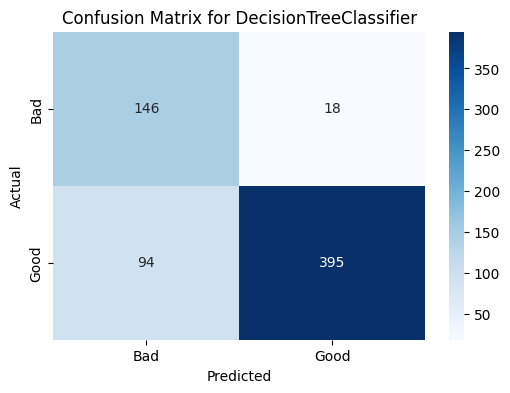

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.61      0.89      0.72       164
        Good       0.96      0.81      0.88       489

    accuracy                           0.83       653
   macro avg       0.78      0.85      0.80       653
weighted avg       0.87      0.83      0.84       653



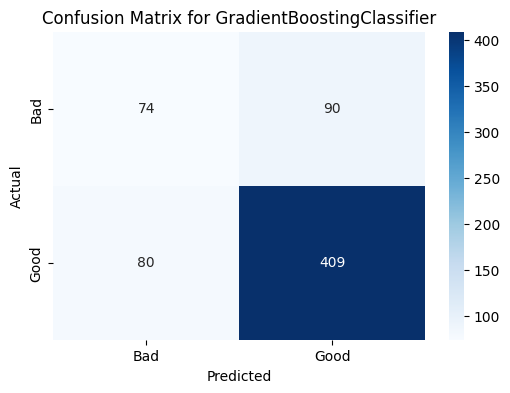

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.48      0.45      0.47       164
        Good       0.82      0.84      0.83       489

    accuracy                           0.74       653
   macro avg       0.65      0.64      0.65       653
weighted avg       0.73      0.74      0.74       653



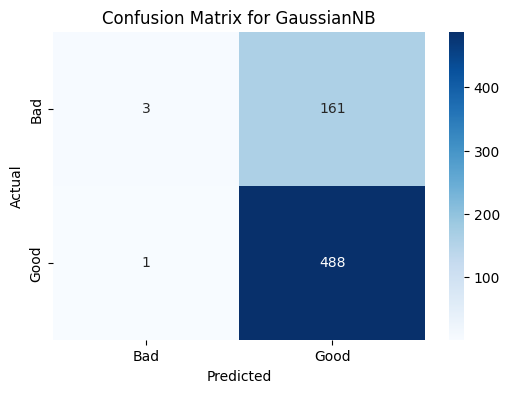

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.75      0.02      0.04       164
        Good       0.75      1.00      0.86       489

    accuracy                           0.75       653
   macro avg       0.75      0.51      0.45       653
weighted avg       0.75      0.75      0.65       653



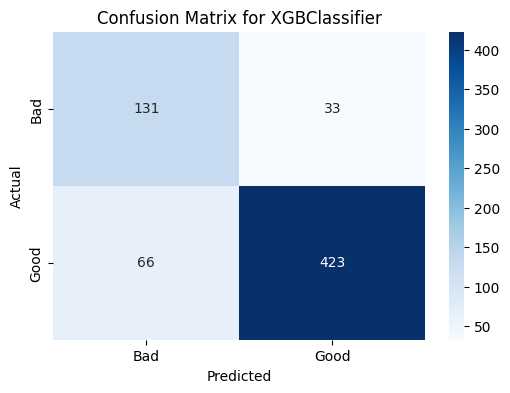

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.66      0.80      0.73       164
        Good       0.93      0.87      0.90       489

    accuracy                           0.85       653
   macro avg       0.80      0.83      0.81       653
weighted avg       0.86      0.85      0.85       653



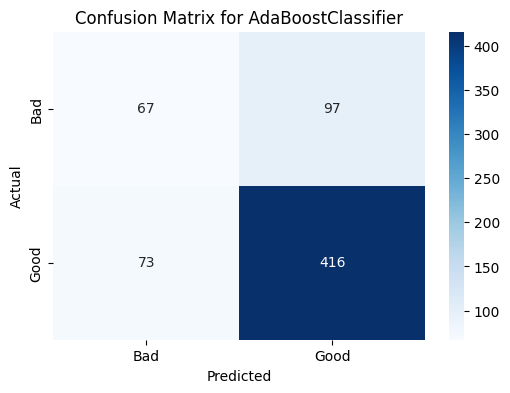

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.48      0.41      0.44       164
        Good       0.81      0.85      0.83       489

    accuracy                           0.74       653
   macro avg       0.64      0.63      0.64       653
weighted avg       0.73      0.74      0.73       653



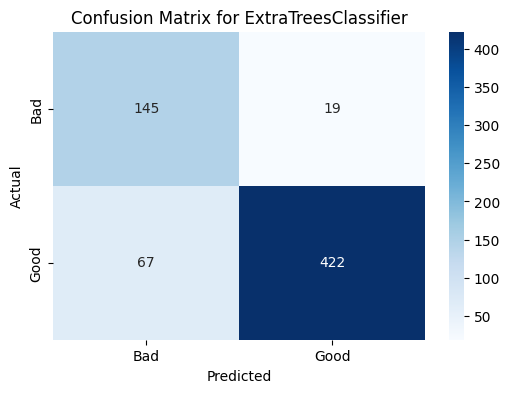

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.68      0.88      0.77       164
        Good       0.96      0.86      0.91       489

    accuracy                           0.87       653
   macro avg       0.82      0.87      0.84       653
weighted avg       0.89      0.87      0.87       653



In [61]:
unseen_X_new2, unseen_y_new2 = prepare_data(good_app_new3, bad_app_new3)
load_and_evaluate_models(unseen_X_new2, unseen_y_new2, model_save_dir, model_names, scaler_path=scaler_path)

In [ ]:
# import shutil
# shutil.make_arvchive('dec size model', 'zip')

# Testing the model regularly with new data collected

In [ ]:
import os
import shutil
import boto3
from tqdm import tqdm
from datetime import datetime, timedelta

# Set the environment variables
# use your AWS credentials insted of these
os.environ['AWS_ACCESS_KEY_ID'] = ''
os.environ['AWS_SECRET_ACCESS_KEY'] = ''

In [3]:
class S3DataDownloader:
    def __init__(self, bucket_name, download_path):
        """
        Initializes the S3DataDownloader instance.

        Args:
            bucket_name (str): The name of the S3 bucket.
            download_path (str): The local directory to download files to.
        """
        self.bucket_name = bucket_name
        self.download_path = download_path
        # Create an S3 client
        self.s3_client = boto3.client('s3')
        self.grouped_objects = self.group_objects_by_date()

    def list_s3_objects(self, bucket_name=None):
        """
        Lists all objects in the specified S3 bucket.

        Args:
            bucket_name (str): The name of the S3 bucket.

        Returns:
            list: A list of objects in the S3 bucket.
        """
        if bucket_name is None:
            bucket_name = self.bucket_name
        object_list = []
        # Use a paginator to iterate through all the objects in the bucket
        paginator = self.s3_client.get_paginator('list_objects_v2')
        page_iterator = paginator.paginate(Bucket=bucket_name)

        for page in page_iterator:
            # Get the list of objects in the current page
            objects = page.get('Contents', [])
            object_list.extend(objects)
        print("\nlist_s3_objects done")
        return object_list

    def group_objects_by_date(self):
        """
        Lists all objects in the S3 bucket & groups them by their last modified date.

        Returns:
            dict: A dictionary where keys are dates and values are lists of object keys.
        """
        objects = self.list_s3_objects()
        grouped_objects = {}
        for obj in objects:
            key = obj['Key']

            # extracting date from key
            date = (key.split('/')[-1])[:8]
            date = date[:4] + '-' + date[4:6] + '-' + date[6:8]

            # extracting date from LastModified
            # timestamp = obj['LastModified']
            # date = str(timestamp.date())

            if date in grouped_objects:
                grouped_objects[date].append(key)
            else:
                grouped_objects[date] = [key]

        # Sort the dictionary based on date values in the keys
        grouped_objects = dict(sorted(grouped_objects.items(),
                                      key=lambda item: item[0]))
        print("group_objects_by_date done\n")
        return grouped_objects

    def replace_misspelled_folder_names(self, species_name):
        misspelled_folders = {
            'Are' : ['Ar', 'Are'],
            'Basa' : ['Basa', 'Basaa'],
            'Barracuda' : ['Barcoda', 'Barkoda', 'Barracoda', 'Barracuda'],
            'Bolo' : ['Bolo', 'Bulo'],
            'Catla' : ['Katala', 'Katalaa', 'Katla'],
            'Croaker' : ['Kokor', 'Croaker', 'Silver croaker'],
            'Chara pona' : ['Chara pana'],
            'Demo' : ['Demo', 'Demo2', 'Test', 'Trial'],
            'Emperor' : ['Comprel', 'Emperor', 'Emporwel', 'Empowel',
                         'M perl', 'M preal'],
            'Hilsa' : ['Hilsa', 'Hilis', 'Hilisa'],
            'Lady' : ['Lady', 'Ledi'],
            'Malabar trevally' : ['Mabar tavili', 'Malbhot', 'Travely', 'Travaily',
                                  'Trvili', 'Trevally', 'Travelly', 'Giant trevally'],
            'Needle' : ['Needale', 'Nidal', 'Nidil'],
            'Parsi' : ['Parci'],
            'Pearl spot' : ['(bloch,', 'Bloch,', 'Bloch',
                            'Pearl spot', 'Pearls spot', 'Hols spot',
                            'Green chromide', 'Green chormide',
                            'Hals spot'],
            'Sea bass' : ['C boss', 'C boos', 'Siba'],
            'Shol' : ['Sholo'],
            'Snapper' : ['Sinper', 'Sniper'],
            'White snapar' : ['White snapper'],
        }

        for key, misspellings in misspelled_folders.items():
            if species_name in misspellings:
                return key
        return species_name

    def download_data(self, date, keys):
        # Create a directory for the date if it doesn't exist
        date_directory = os.path.join(self.download_path, date)
        os.makedirs(date_directory, exist_ok=True)

        # Download each object in the group
        for key in tqdm(keys, desc=f'Downloading {date} data'):
            # Extract fish name and fresh type from the image name
            image_name = key.split('/')[-1]
            try:
                fish_name, fresh_type = image_name.split('_')[-2:]
            except:
                continue
            fresh_type = fresh_type.split('.')[0]
            fish_name = fish_name.capitalize()
            fresh_type = fresh_type.capitalize()

            if fish_name.endswith(" "):
                fish_name = fish_name[:-1]
            if fresh_type.endswith(" "):
                fresh_type = fresh_type[:-1]

            old_fish_name = fish_name

            fish_name = self.replace_misspelled_folder_names(fish_name)

            # if fish_name == "Demo":
            #     continue

#             if fish_name not in ['Sardine', 'Mackerel', 'White prawns']:
#                 continue

            if fish_name not in ('Sardine'):
                continue

            if old_fish_name != fish_name:
                duplicate_folder = os.path.join(date_directory, old_fish_name)
                if os.path.exists(duplicate_folder):
                    shutil.rmtree(duplicate_folder)

            # Create a directory structure:
            # date_folder/fish_name_folder/fresh_type_folder
            fish_directory = os.path.join(date_directory, fish_name)
            fresh_directory = os.path.join(fish_directory, fresh_type)
            
            os.makedirs(fresh_directory, exist_ok=True)
            file_name = os.path.join(fresh_directory, image_name)

            # Download the object if it doesn't already exist locally
            if not os.path.exists(file_name):
                self.s3_client.download_file(self.bucket_name, key, file_name)
            else:
                pass
                # print(f"Skipped (already exists): {file_name}")

    def download_daily_data(self):
        for date, keys in self.grouped_objects.items():
            self.download_data(date, keys)

    def download_specific_date_data(self, specific_date):
        valid_dates = [date for date in self.grouped_objects.keys()]
        print(valid_dates)
        if specific_date not in valid_dates:
            print(f"Data is not collected on : {specific_date}")
            return
        keys = self.grouped_objects[specific_date]
        self.download_data(specific_date, keys)

    def download_weekly_data(self, start_date, end_date):
        for date, keys in self.grouped_objects.items():
            if start_date <= date <= end_date:
                self.download_data(date, keys)

In [4]:
# Example usage
bucket_name='fish-data-collection-v2'
download_path="/kaggle/working/S3 Daily Data"

data_downloader=S3DataDownloader(bucket_name, download_path)

# Download all data daily
# data_downloader.download_daily_data()

# Date should be in YYYY-MM-DD format

# # Download data for a specific date
# specific_date = '2023-05-23'
# data_downloader.download_specific_date_data(specific_date)

# Download data weekly between two dates
start_date = '2024-12-20'
end_date = '2025-01-22'
data_downloader.download_weekly_data(start_date, end_date)


list_s3_objects done
group_objects_by_date done



In [5]:
if os.path.exists('/kaggle/working/Final Data'):
    shutil.rmtree('/kaggle/working/Final Data')
    print('folder deleted successfully!')

## Combining S3 Daily Data

In [6]:
def generate_date_list(start_date, source_dir):
    """
    Generate a list of dates from a specific start date to the end date.

    Parameters:
        start_date (str): Start date in the format 'YYYY-MM-DD'.
        source_dir (str): The source directory containing data organized by dates.

    Returns:
        list: List of dates in the format 'YYYY-MM-DD'.

    """
    all_dates = sorted(os.listdir(source_dir))
    if start_date is None:
        return all_dates

    # list of date folders after the given date in the folder
    dates_list = []
    for date in all_dates:
        if date >= start_date:
            dates_list.append(date)
    return dates_list


def organize_files(source_dir, destination_dir, start_date=None):
    """
    Organize files from source directory to destination directory based on dates.

    Parameters:
        source_dir (str): The source directory containing data organized by dates.
        destination_dir (str): The destination directory to organize the data.
        dates_list (list): List of dates to organize. If None, all dates will be organized.

    """
    os.makedirs(destination_dir, exist_ok=True)
    dates_list = generate_date_list(start_date, source_dir)
    for date in dates_list:
        date_path = os.path.join(source_dir, date)
        if not os.path.isdir(date_path): continue

        for species in tqdm(os.listdir(date_path),
                            desc=f'Loading {date} data'):
            src_species_path = os.path.join(date_path, species)
            des_species_path = os.path.join(destination_dir, species)
            if not os.path.isdir(src_species_path): continue

            for fresh_type in os.listdir(src_species_path):
                src_fresh_type_path = os.path.join(src_species_path, fresh_type)
                des_fresh_type_path = os.path.join(des_species_path, fresh_type)
                if not os.path.isdir(src_fresh_type_path): continue
                os.makedirs(des_fresh_type_path, exist_ok=True)

                for img in os.listdir(src_fresh_type_path):
                    img_path = os.path.join(src_fresh_type_path, img)
                    des_filepath = os.path.join(des_fresh_type_path, img)
                    if not os.path.exists(des_filepath):
                        shutil.copy(img_path, des_filepath)

In [7]:
source_directory = "/kaggle/working/S3 Daily Data"
destination_directory = "/kaggle/working/Final Data"

# For all dates
start_date_str = None
organize_files(source_directory, destination_directory, start_date_str)

# # For dates starting from a specific date
# start_date_str = '2024-09-23'  # Replace with your desired start date
# organize_files(source_directory, destination_directory, start_date_str)

Loading 2024-12-21 data: 0it [00:00, ?it/s]
Loading 2024-12-26 data: 100%|██████████| 1/1 [00:00<00:00, 12.50it/s]
Loading 2024-12-28 data: 0it [00:00, ?it/s]
Loading 2025-01-21 data: 100%|██████████| 1/1 [00:00<00:00,  8.45it/s]


## Creating Dataframes

In [8]:
# Pip install method (recommended)
# !pip install ultralytics==8.0.20
!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.65 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6096.0/8062.4 GB disk)


In [9]:
from ultralytics import YOLO

In [10]:
fish_model = YOLO('/kaggle/input/unseen-tomato-images-dataset/fish.pt')
# scale_model = YOLO('/kaggle/input/unseen-tomato-images-dataset/best.pt')
scale_model = YOLO("/kaggle/input/unseen-tomato-images-dataset/multiple_scale_detection_model.pt")

In [11]:
def circumference_area(img):
    image = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, binary_mask = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        circumference = cv2.arcLength(largest_contour, closed=True)
        area = cv2.contourArea(largest_contour)
        return circumference, area
    else:
        return 0, 0

def get_object_height(results, index=0):
    hp = int(results[0].boxes.xywh[index][3])
    wp = int(results[0].boxes.xywh[index][2])
    dp = int(math.hypot(hp, wp))
    if hp < wp:
        hp, wp = wp, hp
    return hp, wp, dp

def pixel_to_cm(fish_hp, fish_wp, fish_dp, scale_hp, scale_wp, scale_dp):
    try:
        scale_hcm = 15
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except Exception:
        (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)

    return fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, one_pixel_value

def single_img_data(fish_hp, fish_wp, fish_dp, scale_hp, scale_wp, scale_dp, fish_img, img_area):
    fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, one_pixel_value = pixel_to_cm(
        fish_hp, fish_wp, fish_dp, scale_hp, scale_wp, scale_dp
    )
    aspect_ratio = fish_wcm / fish_hcm if fish_hcm != 0 else 0
    diagonal_to_height_ratio = fish_dp / fish_hp if fish_hp != 0 else 0
    circumference, area = circumference_area(fish_img)
    area_ratio = area / img_area if img_area != 0 else 0

    if one_pixel_value != 0:
        circumference = int(circumference * one_pixel_value)
        area = int(area * one_pixel_value * one_pixel_value)

    data = {
        'FishHeight(cm)': fish_hcm,
        'FishWidth(cm)': fish_wcm,
        'FishDiagonal(cm)': fish_dcm,
        'ScaleDiagonal(cm)': scale_dcm,
        'ScaleWidth(cm)': scale_wcm,
        'OnePixelValue': one_pixel_value,
        'Circumference(cm)': circumference,
        'Area(cm)': area,
        'AspectRatio': aspect_ratio,
        'DiagonalToHeightRatio': diagonal_to_height_ratio,
        'AreaRatio': area_ratio
    }

    return pd.DataFrame([data])

def get_segmented_img(pred, white_background=False):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []

    for mask in masks:
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        segment_image = masked_img[y:y+h, x:x+w]

        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]

        seg_img_list.append(segment_image)

    return seg_img_list

In [12]:
def get_img_df(img_path, img_name):
    results = fish_model(img_path, imgsz=640, conf=0.75, iou=0.7, verbose=False)
    if len(results[0].boxes.cls) == 0:
        return pd.DataFrame([{'SegmentedFilename': img_name, 'FishDetected': 'no'}])

    scale_results = scale_model(img_path, imgsz=640, conf=0.5, iou=0.7, verbose=False)
    if len(scale_results[0].boxes.cls) == 0:
        return pd.DataFrame([{'SegmentedFilename': img_name, 'FishDetected': 'yes', 'ScaleDetected': 'no'}])

    seg_img_list = get_segmented_img(results[0], white_background=False)
    image_width, image_height = results[0].orig_shape[1], results[0].orig_shape[0]
    image_area = image_width * image_height

    scale_hp, scale_wp, scale_dp = get_object_height(scale_results)
    dfs = []
    for i, img in enumerate(seg_img_list):
        fish_hp, fish_wp, fish_dp = get_object_height(results, i)
        df = single_img_data(fish_hp, fish_wp, fish_dp, scale_hp, scale_wp, scale_dp, img, image_area)
        df['SegmentedFilename'] = img_name.split('.')[0] + f'_({i}).png'
        df['FishDetected'] = 'yes'
        df['ScaleDetected'] = 'yes'
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else None

In [13]:
csv_path = 'scale_based_size_bad_data_dec20tojan7.csv'
if os.path.exists('/kaggle/working/scale_based_size_bad_data_dec19tojan2.csv'):
    os.remove('/kaggle/working/scale_based_size_bad_data_dec19tojan2.csv')
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    df = pd.DataFrame()

dir_path = '/kaggle/working/Final Data/Sardine/Bad'

# Process images
for img in tqdm(sorted(os.listdir(dir_path))):
    img_path = os.path.join(dir_path, img)
    new_df = get_img_df(img_path, img)
    if new_df is not None:
        df = pd.concat([df, new_df], ignore_index=True)
        df.to_csv(csv_path, index=False)

df.shape

100%|██████████| 66/66 [00:18<00:00,  3.53it/s]


(145, 14)

In [14]:
csv_path = 'scale_based_size_good_data_dec20tojan7.csv'
if os.path.exists('/kaggle/working/scale_based_size_good_data_dec19tojan2.csv'):
    os.remove('/kaggle/working/scale_based_size_good_data_dec19tojan2.csv')
    
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    df = pd.DataFrame()

dir_path = '/kaggle/working/Final Data/Sardine/Good'

# Process images
for img in tqdm(sorted(os.listdir(dir_path))):
    img_path = os.path.join(dir_path, img)
    new_df = get_img_df(img_path, img)
    if new_df is not None:
        df = pd.concat([df, new_df], ignore_index=True)
        df.to_csv(csv_path, index=False)

df.shape

100%|██████████| 764/764 [02:49<00:00,  4.50it/s]


(1557, 14)

In [62]:
good_dec = pd.read_csv('/kaggle/working/scale_based_size_good_data_dec20tojan7.csv')
bad_dec = pd.read_csv('/kaggle/working/scale_based_size_bad_data_dec20tojan7.csv')

good_dec.dropna(inplace=True)
bad_dec.dropna(inplace=True)

cols_to_drop = ['FishDetected', 'SegmentedFilename', 'ScaleDetected']
good_dec.drop(columns=cols_to_drop, inplace=True)
bad_dec.drop(columns=cols_to_drop, inplace=True)

good_dec.shape, bad_dec.shape

((1556, 11), (145, 11))

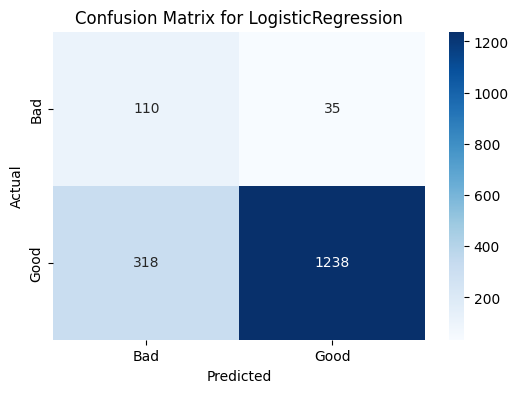

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.26      0.76      0.38       145
        Good       0.97      0.80      0.88      1556

    accuracy                           0.79      1701
   macro avg       0.61      0.78      0.63      1701
weighted avg       0.91      0.79      0.83      1701



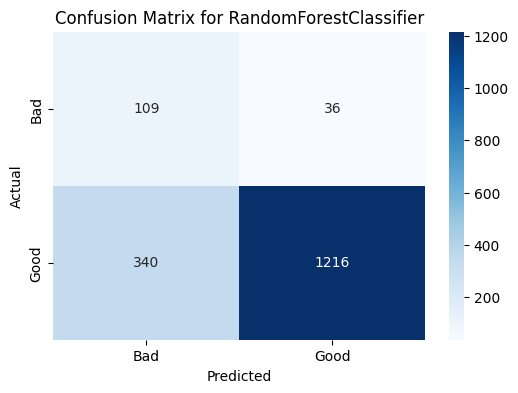

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.24      0.75      0.37       145
        Good       0.97      0.78      0.87      1556

    accuracy                           0.78      1701
   macro avg       0.61      0.77      0.62      1701
weighted avg       0.91      0.78      0.82      1701



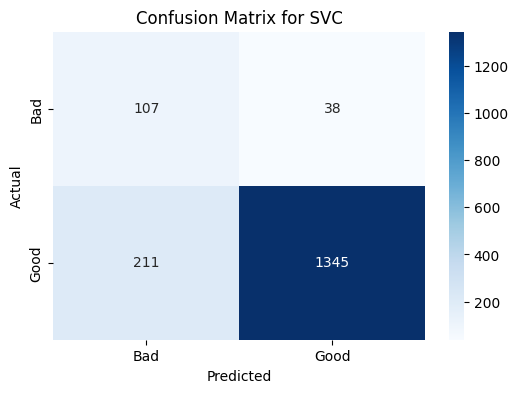

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.34      0.74      0.46       145
        Good       0.97      0.86      0.92      1556

    accuracy                           0.85      1701
   macro avg       0.65      0.80      0.69      1701
weighted avg       0.92      0.85      0.88      1701



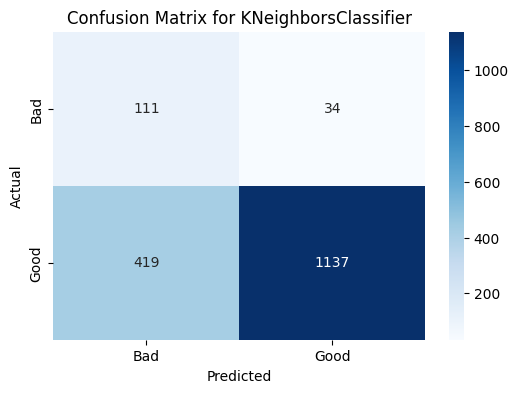

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.21      0.77      0.33       145
        Good       0.97      0.73      0.83      1556

    accuracy                           0.73      1701
   macro avg       0.59      0.75      0.58      1701
weighted avg       0.91      0.73      0.79      1701



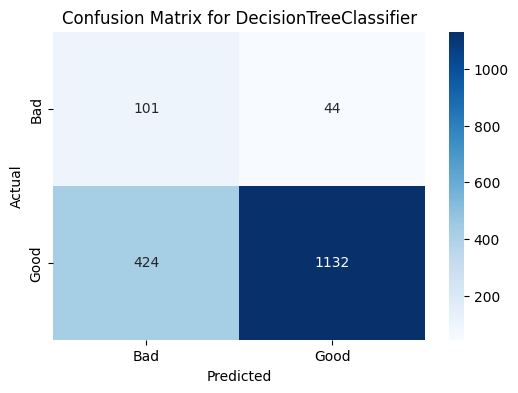

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.19      0.70      0.30       145
        Good       0.96      0.73      0.83      1556

    accuracy                           0.72      1701
   macro avg       0.58      0.71      0.57      1701
weighted avg       0.90      0.72      0.78      1701



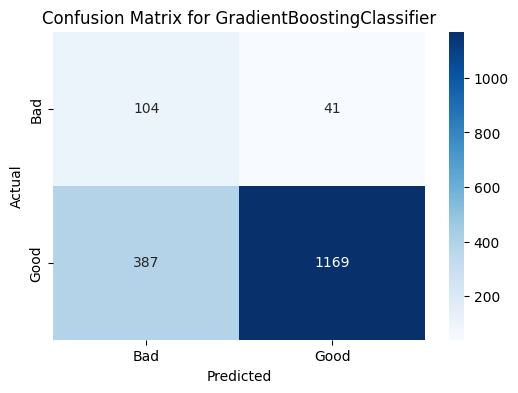

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.21      0.72      0.33       145
        Good       0.97      0.75      0.85      1556

    accuracy                           0.75      1701
   macro avg       0.59      0.73      0.59      1701
weighted avg       0.90      0.75      0.80      1701



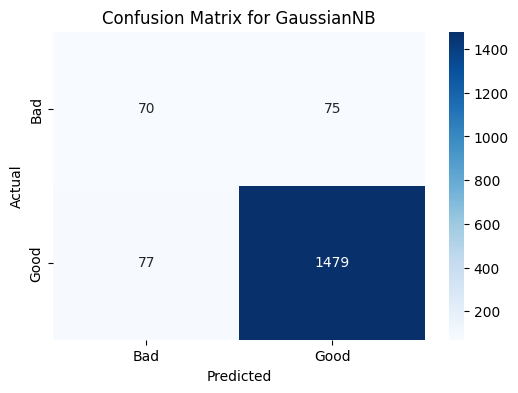

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.48      0.48      0.48       145
        Good       0.95      0.95      0.95      1556

    accuracy                           0.91      1701
   macro avg       0.71      0.72      0.72      1701
weighted avg       0.91      0.91      0.91      1701



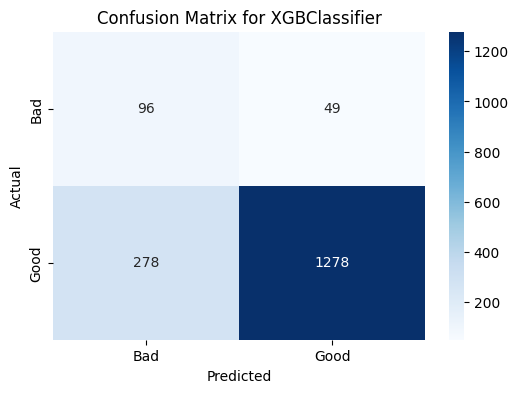

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.26      0.66      0.37       145
        Good       0.96      0.82      0.89      1556

    accuracy                           0.81      1701
   macro avg       0.61      0.74      0.63      1701
weighted avg       0.90      0.81      0.84      1701



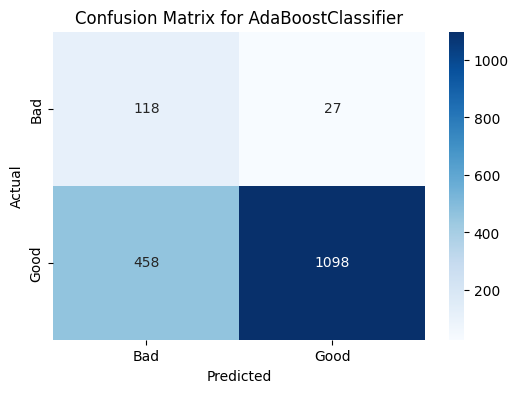

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.20      0.81      0.33       145
        Good       0.98      0.71      0.82      1556

    accuracy                           0.71      1701
   macro avg       0.59      0.76      0.57      1701
weighted avg       0.91      0.71      0.78      1701



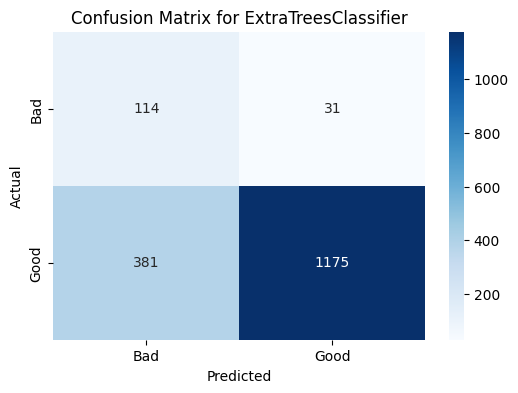

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.23      0.79      0.36       145
        Good       0.97      0.76      0.85      1556

    accuracy                           0.76      1701
   macro avg       0.60      0.77      0.60      1701
weighted avg       0.91      0.76      0.81      1701



In [63]:
unseen_X_dec2jan, unseen_y_dec2jan = prepare_data(good_dec, bad_dec)
# Example usage
model_save_dir = '/kaggle/working/Classification models'
scaler_path = '/kaggle/working/Classification models/scaler_classification.pkl'  # Path to the saved scaler used during training

model_names = [
    "LogisticRegression", "RandomForestClassifier", "SVC", "KNeighborsClassifier",
    "DecisionTreeClassifier", "GradientBoostingClassifier", "GaussianNB",
    "XGBClassifier", "AdaBoostClassifier", "ExtraTreesClassifier"
]

# Evaluate all saved models on unseen data
load_and_evaluate_models(unseen_X_dec2jan, unseen_y_dec2jan, model_save_dir, model_names, scaler_path=scaler_path)

# Download App Testing Data

In [15]:
!pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 43.1 MB/s eta 0:00:0000:0100:01


In [ ]:
import psycopg2
import pandas as pd
import os
import boto3
from tqdm import tqdm

conn = psycopg2.connect(
    dbname="",
    user="",
    password="",
    host="",
    port="5432"
)
cur = conn.cursor()
# cur.execute("SELECT * FROM fishinfo")  #Download whole table
cur.execute('SELECT * FROM "Feedback"') # Download rows after specific id (TO DOWNLOAD ONLY NEW IMAGES)
rows = cur.fetchall()
column_names = [desc[0] for desc in cur.description]
df = pd.DataFrame(rows, columns=column_names)
cur.close()
conn.close()
df.head()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason
0,1,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,B,G,G,False,2023-11-23 04:11:45.771266+00:00,demo,None
1,2,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:02.582968+00:00,demo,None
2,3,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:24.689801+00:00,demo,None
3,4,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:13:19.877843+00:00,demo,None
4,5,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,B,False,2023-11-23 04:13:46.147758+00:00,demo,None


In [17]:
# df = df[df['user_name']=='demo'].reset_index(drop=True)
df['Date'] = df['input_image_url'].apply(lambda x: x.split('/')[-2])
df['Species'] = df['input_image_url'].apply(lambda x: x.split('/')[-1].split('_')[-2])

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def get_filename(url):
    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    filename = os.path.basename(object_key)
    return filename

df['filename'] = df['input_image_url'].apply(get_filename)
df['filename_id'] = df['filename'].apply(lambda x: x.split('_')[2])
df = df[df['user_name']!='test']
df = df.dropna(subset=['user_name'])
df = df.drop_duplicates(subset='filename_id', keep='first')

def filter_df(df, filters={}):
    """
    Filter a pandas DataFrame based on specified conditions for each column.

    Parameters:
    - df (pd.DataFrame): The DataFrame to be filtered.
    - filters (dict): A dictionary where keys are column names, and values are the conditions
                     to filter on. Values can be a single value or a list of values for each column.

    Returns:
    pd.DataFrame: A new DataFrame containing only the rows that satisfy the specified conditions.

    Example:
    >>> filters = {'column1': value1, 'column2': [value2a, value2b], 'column3': value3}
    >>> result_df = filter_df(your_dataframe, filters)
    """

    if not filters:
        return df  # If no filters provided, return the original DataFrame

    # Initialize a boolean mask to True for all rows
    mask = [True] * len(df)

    # Apply filters for each column and its corresponding values in the dictionary
    for col, vals in filters.items():
        if not isinstance(vals, list):
            vals = [vals]  # Convert single value to a list

        mask &= df[col].isin(vals)

    # Use the boolean mask to filter the DataFrame
    filtered_df = df[mask]

    return filtered_df

def conf_matrix(df, species='mackerel'):
    # Assuming df is your DataFrame
    actual_values = df[['fish1_actual', 'fish2_actual', 'fish3_actual']].values.flatten()
    predicted_values = df[['fish1_pred', 'fish2_pred', 'fish3_pred']].values.flatten()
    actual_values = actual_values[actual_values != None]
    predicted_values = predicted_values[predicted_values != None]

    # Create a confusion matrix
    conf_matrix = confusion_matrix(actual_values, predicted_values, labels=['G', 'B'])

    # Display the confusion matrix
    conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Good', 'Actual Bad'],
                                  columns=['Predicted Good', 'Predicted Bad'])
    print('\t'*3, species, 'results', '\n'*2, conf_matrix_df)

def print_classification_report_v1(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)
    
    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=["Good", "Bad"],
                                   zero_division=1)

    # Print the classification report
    print(report)

def print_classification_report(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)
    
    label_map = {'Bad':0, 'Good':1}
    class_labels = list(label_map.keys())

    unique_class_labels = list(set(true_labels) | set(predicted_labels))
    
    # Create a target_names list based on the unique class labels
    new_class_labels = [k for k, v in label_map.items() if v in unique_class_labels]
    
    # Convert true labels and predictions to class names
    true_class_names = [class_labels[i] for i in true_labels]
    predicted_class_names = [class_labels[i] for i in predicted_labels]
    
    # cm = confusion_matrix(true_class_names, predicted_class_names, 
    #                       labels=new_class_labels)

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels, 
                                   target_names=new_class_labels,
                                   zero_division=1)

    print(report)

def plot_confusion_matrix(cm, new_class_labels, title='Confusion Matrix'):
    labels = new_class_labels    
    num_labels = len(labels)
    fig_size = max(5, num_labels)  # Ensure a minimum size of 5x5
    print_classification_report_v1(cm)
    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,\
              xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

def get_unique_values(df, column_names):
    """
    Get unique values for a list of column names in a DataFrame.

    Parameters:
    - df (pd.DataFrame): The DataFrame to extract unique values from.
    - column_names (list): A list of column names for which to find unique values.

    Returns:
    dict: A dictionary where keys are column names, and values are lists of unique values.
    """
    unique_values_dict = {}

    for col in column_names:
        unique_values_dict[col] = df[col].unique().tolist()

    return unique_values_dict

# Example usage:
column_names = ['Date', 'Species']
unique_values = get_unique_values(df, column_names)
print(unique_values)

{'Date': ['2023-11-23', '2023-11-25', '2023-11-28', '2023-11-29', '2025-01-21', '2023-11-30', '2023-12-05', '2023-12-06', '2023-12-07', '2023-12-08', '2023-12-12', '2023-12-13', '2023-12-14', '2023-12-15', '2023-12-19', '2023-12-23', '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12', '2024-01-16', '2024-01-18', '2024-01-19', '2024-01-23', '2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-13', '2024-02-16', '2024-02-20', '2024-02-21', '2024-02-22', '2024-02-23', '2024-02-25', '2024-02-28', '2023-11-01', '2024-02-29', '2024-03-01', '2024-03-05', '2024-03-06', '2024-03-12', '2024-03-13', '2024-03-14', '2024-03-15', '2024-03-19', '2024-03-21', '2024-03-22', '2024-03-26', '2024-03-27', '2024-03-28', '2024-04-02', '2024-04-03', '2024-04-04', '2024-04-05', '2024-04-09', '2024-04-11', '2024-04-18', '2024-04-23', '2024-04-25', '2024-05-02', '2024-05-07', '2024-05-0

In [19]:
filters = {'Species': ['sardine'], 'Date': ['2025-01-21']}

result_df = filter_df(df, filters)
conf_matrix(result_df, 'sardine')

			 sardine results 

              Predicted Good  Predicted Bad
Actual Good             208             64
Actual Bad               34             46


/tmp/ipykernel_34/3345901588.py:48: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  mask &= df[col].isin(vals)


	tp: 75, fn: 18, fp: 0, tn: 17

              precision    recall  f1-score   support

        Good       1.00      0.81      0.89        93
         Bad       0.49      1.00      0.65        17

    accuracy                           0.84       110
   macro avg       0.74      0.90      0.77       110
weighted avg       0.92      0.84      0.86       110



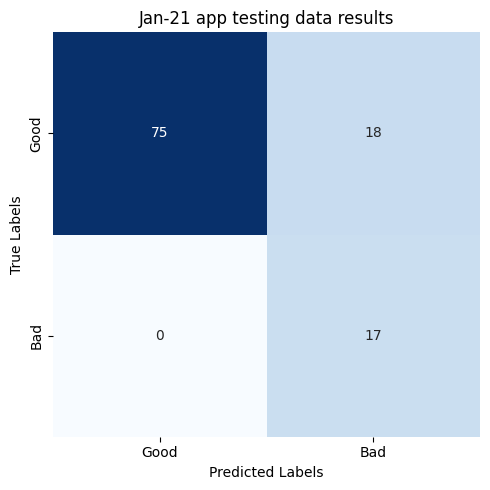

In [22]:
cm = np.array([[75, 18], [0, 17]])
plot_confusion_matrix(cm, ['Good', 'Bad'], 'Jan-21 app testing data results')

In [ ]:
import os

os.environ['AWS_ACCESS_KEY_ID'] = ''
os.environ['AWS_SECRET_ACCESS_KEY'] = ''

In [21]:
from urllib.parse import urlparse

def download_object_from_s3(url, destination_folder,
                            bucket_name='fish-data-collection'):

    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    new_object_key = object_key.replace(':', '_') # for windows os

    filename = os.path.join(destination_folder, os.path.basename(object_key))
    # print(f'Parsed URL: {parsed_url}\nBucket name: {bucket_name}\nObject key: {object_key}\n')

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    if os.path.exists(filename):
        return

    # Initialize a Boto3 S3 client
    s3 = boto3.client('s3')

    # Download the object
    try:
        response = s3.download_file(Bucket = bucket_name,
                                    Key = object_key,
                                    Filename = filename)
        # print('Object downloaded successfully.')
    except Exception as e:
        print('Error:', str(e))

In [22]:
destination_folder = "/kaggle/working/"
bucket_name = 'mobile-api-results-v2'

In [23]:
def download_images_to_folder(df, destination_folder,
                              bucket_name = 'mobile-api-results-v2'):

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    d = {'G': 'Good', 'B': 'Bad'}

    for index, row in tqdm(df.iterrows()):
        input_url = row[1]
        output_url = row[2]
        species = row[-3]
        date = row[-4]
        try:
            label = d[row[3]]
        except:
            continue
        input_folder = os.path.join(destination_folder, 'input', date, species, label)
        output_folder = os.path.join(destination_folder, 'output', date, species)

        # Download input image
        download_object_from_s3(input_url, input_folder, bucket_name)

        # Download output image
        download_object_from_s3(output_url, output_folder, bucket_name)

    print('Images downloaded successfully.')

# Example usage:
# df is your DataFrame containing input and output URLs in columns 1 and 2
# destination_folder is the folder where you want to save the images
# download_images_to_folder(result_df, destination_folder)
# download_images_to_folder(df, destination_folder)

In [24]:
# download_images_to_folder(result_df, destination_folder)

In [25]:
# species_list = ['sardine', 'white prawn', 'mackerel']

# date_range = ['2024-10-09', '2024-12-01'] # starting should be 2024-10-09

# date_range = ['2024-12-10', '2024-12-22']

date_range = ['2024-12-20', '2025-01-22']

all_dates = sorted(df.Date.unique())
date_list = [date for date in all_dates if date_range[0] <= date <= date_range[1]]

for date in date_list:
    filters = {'Species': ['sardine'], 'Date': [date]}
    # filters = {'Species': ['white prawn'], 'Date': [date]}
#     filters = {'Species': ['mackerel'], 'Date': [date]}
    result_df = filter_df(df, filters)
    if result_df.empty: continue
    download_images_to_folder(result_df, destination_folder, bucket_name)
    print(f'Downloaded images for {date}\n')

/tmp/ipykernel_34/3345901588.py:48: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  mask &= df[col].isin(vals)
0it [00:00, ?it/s]/tmp/ipykernel_34/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_34/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_34/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is depr

Images downloaded successfully.
Downloaded images for 2024-12-24



0it [00:00, ?it/s]/tmp/ipykernel_34/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_34/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_34/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = row[-3]
/tmp/ipykernel_34/2168773426.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In 

Images downloaded successfully.
Downloaded images for 2024-12-26



0it [00:00, ?it/s]/tmp/ipykernel_34/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_34/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_34/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = row[-3]
/tmp/ipykernel_34/2168773426.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In 

Images downloaded successfully.
Downloaded images for 2025-01-02



0it [00:00, ?it/s]/tmp/ipykernel_34/2168773426.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  input_url = row[1]
/tmp/ipykernel_34/2168773426.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  output_url = row[2]
/tmp/ipykernel_34/2168773426.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  species = row[-3]
/tmp/ipykernel_34/2168773426.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In 

Images downloaded successfully.
Downloaded images for 2025-01-21



In [26]:
def generate_date_list(start_date, source_dir):
    """
    Generate a list of dates from a specific start date to the end date.

    Parameters:
        start_date (str): Start date in the format 'YYYY-MM-DD'.
        source_dir (str): The source directory containing data organized by dates.

    Returns:
        list: List of dates in the format 'YYYY-MM-DD'.

    """
    all_dates = sorted(os.listdir(source_dir))
    if start_date is None:
        return all_dates

    # list of date folders after the given date in the folder
    dates_list = []
    for date in all_dates:
        if date >= start_date:
            dates_list.append(date)
    return dates_list


def organize_files(source_dir, destination_dir, start_date=None):
    """
    Organize files from source directory to destination directory based on dates.

    Parameters:
        source_dir (str): The source directory containing data organized by dates.
        destination_dir (str): The destination directory to organize the data.
        dates_list (list): List of dates to organize. If None, all dates will be organized.

    """
    os.makedirs(destination_dir, exist_ok=True)
    dates_list = generate_date_list(start_date, source_dir)
    for date in dates_list:
        date_path = os.path.join(source_dir, date)
        if not os.path.isdir(date_path): continue

        for species in tqdm(os.listdir(date_path),
                            desc=f'Loading {date} data'):
            src_species_path = os.path.join(date_path, species)
            des_species_path = os.path.join(destination_dir, species)
            if not os.path.isdir(src_species_path): continue

            for fresh_type in os.listdir(src_species_path):
                src_fresh_type_path = os.path.join(src_species_path, fresh_type)
                des_fresh_type_path = os.path.join(des_species_path, fresh_type)
                if not os.path.isdir(src_fresh_type_path): continue
                os.makedirs(des_fresh_type_path, exist_ok=True)

                for img in os.listdir(src_fresh_type_path):
                    img_path = os.path.join(src_fresh_type_path, img)
                    des_filepath = os.path.join(des_fresh_type_path, img)
                    if not os.path.exists(des_filepath):
                        shutil.copy(img_path, des_filepath)

In [27]:
source_directory = "/kaggle/working/input"
destination_directory = "/kaggle/working/App Testing Data"

# For all dates
start_date_str = None
organize_files(source_directory, destination_directory, start_date_str)

# # For dates starting from a specific date
# start_date_str = '2024-09-23'  # Replace with your desired start date
# organize_files(source_directory, destination_directory, start_date_str)

Loading 2025-01-21 data: 100%|██████████| 1/1 [00:00<00:00, 40.94it/s]


In [28]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [29]:
csv_path = 'scale_based_size_bad_app_data_dec20tojan7.csv'
if os.path.exists('/kaggle/working/scale_based_size_bad_app_data_dec20tojan7.csv'):
    print('file exists')
    os.remove('/kaggle/working/scale_based_size_bad_app_data_dec20tojan7.csv')
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    df = pd.DataFrame()

dir_path = '/kaggle/working/App Testing Data/sardine/Bad'

# Process images
for img in tqdm(sorted(os.listdir(dir_path))):
    img_path = os.path.join(dir_path, img)
    new_df = get_img_df(img_path, img)
    if new_df is not None:
        df = pd.concat([df, new_df], ignore_index=True)
        df.to_csv(csv_path, index=False)

df.shape

100%|██████████| 90/90 [00:04<00:00, 18.91it/s]


(172, 14)

In [30]:
csv_path = 'scale_based_size_good_app_data_dec20tojan7.csv'
if os.path.exists('/kaggle/working/scale_based_size_good_app_data_dec20tojan7.csv'):
    os.remove('/kaggle/working/scale_based_size_good_app_data_dec20tojan7.csv')
    
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    df = pd.DataFrame()

dir_path = '/kaggle/working/App Testing Data/sardine/Good'

# Process images
for img in tqdm(sorted(os.listdir(dir_path))):
    img_path = os.path.join(dir_path, img)
    new_df = get_img_df(img_path, img)
    if new_df is not None:
        df = pd.concat([df, new_df], ignore_index=True)
        df.to_csv(csv_path, index=False)

df.shape

100%|██████████| 269/269 [00:13<00:00, 19.67it/s]


(514, 14)

In [64]:
good_dec = pd.read_csv('/kaggle/working/scale_based_size_good_data_dec20tojan7.csv')
bad_dec = pd.read_csv('/kaggle/working/scale_based_size_bad_data_dec20tojan7.csv')

good_dec.dropna(inplace=True)
bad_dec.dropna(inplace=True)

cols_to_drop = ['FishDetected', 'SegmentedFilename', 'ScaleDetected']
good_dec.drop(columns=cols_to_drop, inplace=True)
bad_dec.drop(columns=cols_to_drop, inplace=True)

good_dec.shape, bad_dec.shape

((1556, 11), (145, 11))

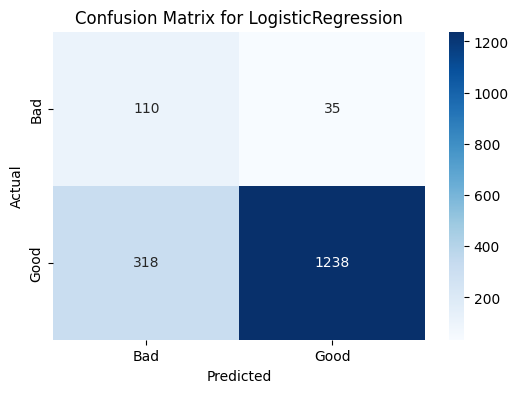

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.26      0.76      0.38       145
        Good       0.97      0.80      0.88      1556

    accuracy                           0.79      1701
   macro avg       0.61      0.78      0.63      1701
weighted avg       0.91      0.79      0.83      1701



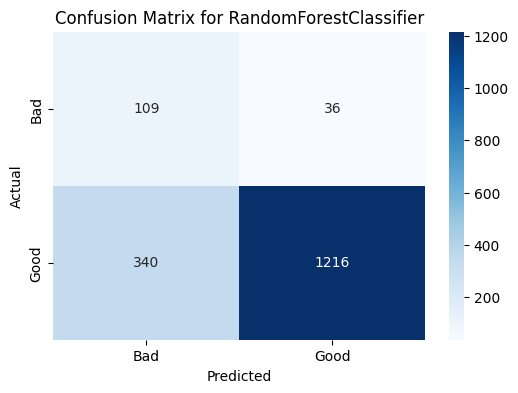

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.24      0.75      0.37       145
        Good       0.97      0.78      0.87      1556

    accuracy                           0.78      1701
   macro avg       0.61      0.77      0.62      1701
weighted avg       0.91      0.78      0.82      1701



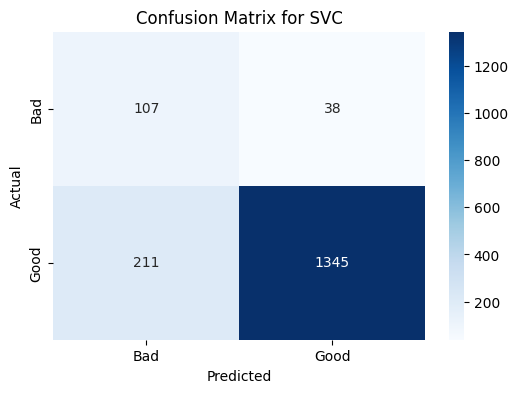

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.34      0.74      0.46       145
        Good       0.97      0.86      0.92      1556

    accuracy                           0.85      1701
   macro avg       0.65      0.80      0.69      1701
weighted avg       0.92      0.85      0.88      1701



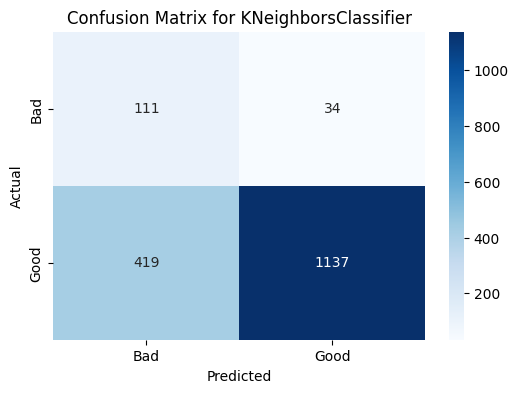

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.21      0.77      0.33       145
        Good       0.97      0.73      0.83      1556

    accuracy                           0.73      1701
   macro avg       0.59      0.75      0.58      1701
weighted avg       0.91      0.73      0.79      1701



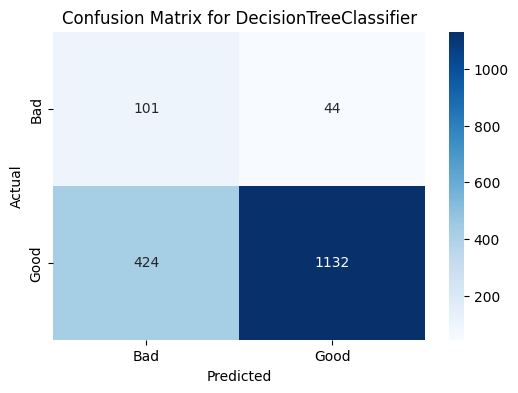

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.19      0.70      0.30       145
        Good       0.96      0.73      0.83      1556

    accuracy                           0.72      1701
   macro avg       0.58      0.71      0.57      1701
weighted avg       0.90      0.72      0.78      1701



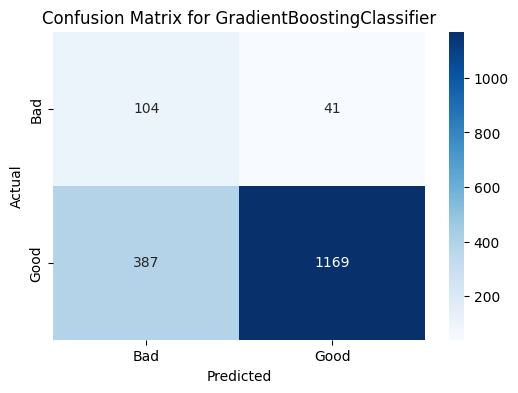

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.21      0.72      0.33       145
        Good       0.97      0.75      0.85      1556

    accuracy                           0.75      1701
   macro avg       0.59      0.73      0.59      1701
weighted avg       0.90      0.75      0.80      1701



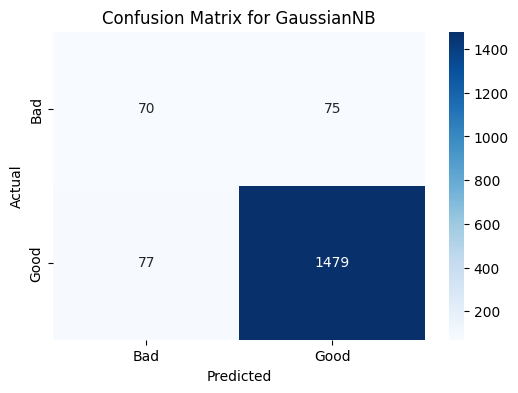

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.48      0.48      0.48       145
        Good       0.95      0.95      0.95      1556

    accuracy                           0.91      1701
   macro avg       0.71      0.72      0.72      1701
weighted avg       0.91      0.91      0.91      1701



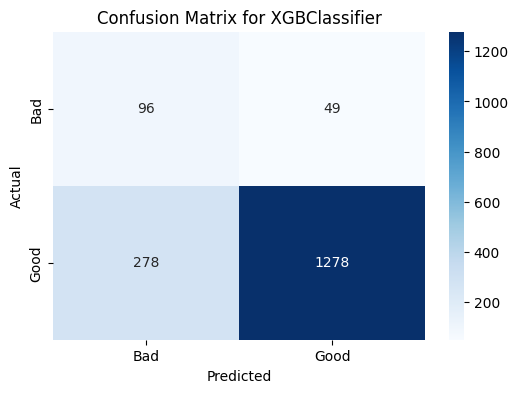

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.26      0.66      0.37       145
        Good       0.96      0.82      0.89      1556

    accuracy                           0.81      1701
   macro avg       0.61      0.74      0.63      1701
weighted avg       0.90      0.81      0.84      1701



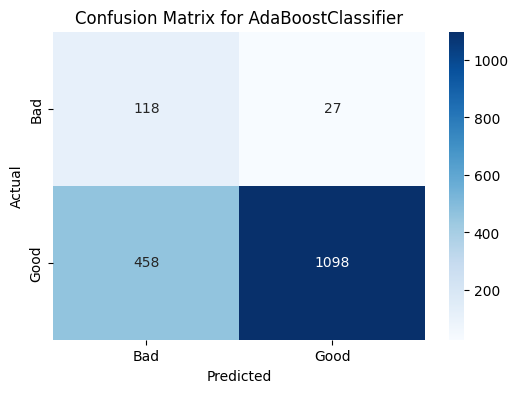

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.20      0.81      0.33       145
        Good       0.98      0.71      0.82      1556

    accuracy                           0.71      1701
   macro avg       0.59      0.76      0.57      1701
weighted avg       0.91      0.71      0.78      1701



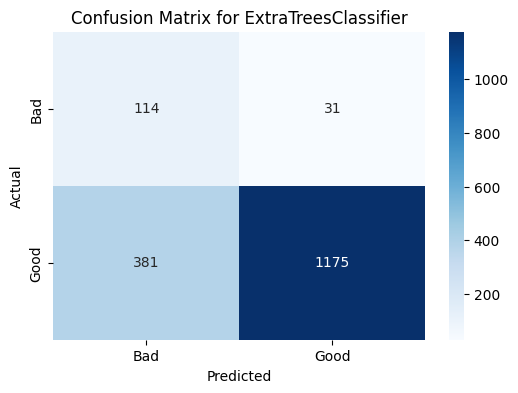

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.23      0.79      0.36       145
        Good       0.97      0.76      0.85      1556

    accuracy                           0.76      1701
   macro avg       0.60      0.77      0.60      1701
weighted avg       0.91      0.76      0.81      1701



In [65]:
unseen_X_dec2jan_app, unseen_y_dec2jan_app = prepare_data(good_dec, bad_dec)
# Example usage
model_save_dir = '/kaggle/working/Classification models'
scaler_path = '/kaggle/working/Classification models/scaler_classification.pkl'  # Path to the saved scaler used during training

model_names = [
    "LogisticRegression", "RandomForestClassifier", "SVC", "KNeighborsClassifier",
    "DecisionTreeClassifier", "GradientBoostingClassifier", "GaussianNB",
    "XGBClassifier", "AdaBoostClassifier", "ExtraTreesClassifier"
]

# Evaluate all saved models on unseen data
load_and_evaluate_models(unseen_X_dec2jan_app, unseen_y_dec2jan_app, model_save_dir, model_names, scaler_path=scaler_path)

In [79]:
good_dec = pd.read_csv('/kaggle/working/scale_based_size_good_data_dec20tojan7.csv')
bad_dec = pd.read_csv('/kaggle/working/scale_based_size_bad_data_dec20tojan7.csv')

good_dec2 = filter_df_by_date(good_dec, '20241226', greater=True)
bad_dec2 = filter_df_by_date(bad_dec, '20241226', greater=True)

good_dec2.dropna(inplace=True)
bad_dec2.dropna(inplace=True)

cols_to_drop = ['FishDetected', 'SegmentedFilename', 'ScaleDetected']
good_dec2.drop(columns=cols_to_drop, inplace=True)
bad_dec2.drop(columns=cols_to_drop, inplace=True)

good_dec2.shape, bad_dec2.shape

((1478, 11), (143, 11))

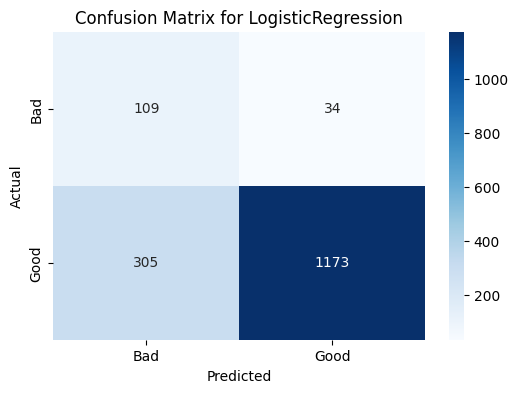

Classification Report for LogisticRegression on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.26      0.76      0.39       143
        Good       0.97      0.79      0.87      1478

    accuracy                           0.79      1621
   macro avg       0.62      0.78      0.63      1621
weighted avg       0.91      0.79      0.83      1621



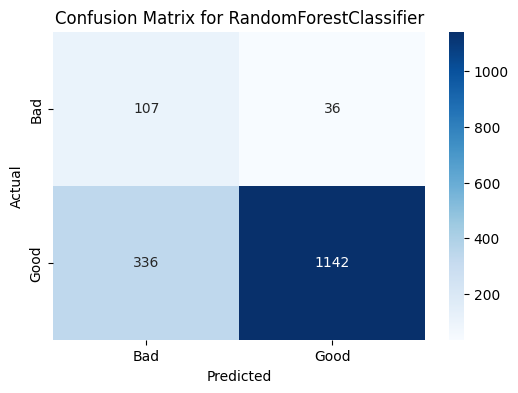

Classification Report for RandomForestClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.24      0.75      0.37       143
        Good       0.97      0.77      0.86      1478

    accuracy                           0.77      1621
   macro avg       0.61      0.76      0.61      1621
weighted avg       0.91      0.77      0.82      1621



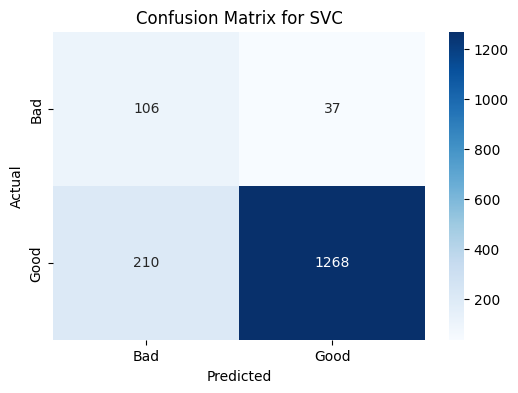

Classification Report for SVC on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.34      0.74      0.46       143
        Good       0.97      0.86      0.91      1478

    accuracy                           0.85      1621
   macro avg       0.65      0.80      0.69      1621
weighted avg       0.92      0.85      0.87      1621



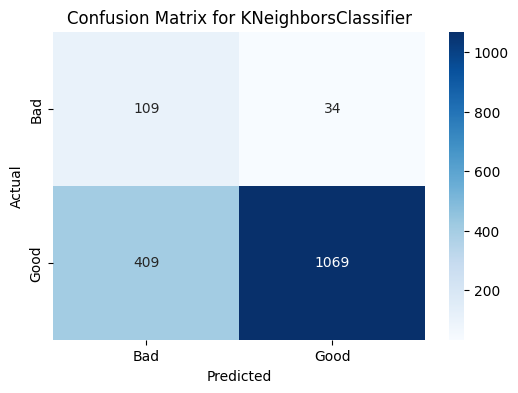

Classification Report for KNeighborsClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.21      0.76      0.33       143
        Good       0.97      0.72      0.83      1478

    accuracy                           0.73      1621
   macro avg       0.59      0.74      0.58      1621
weighted avg       0.90      0.73      0.78      1621



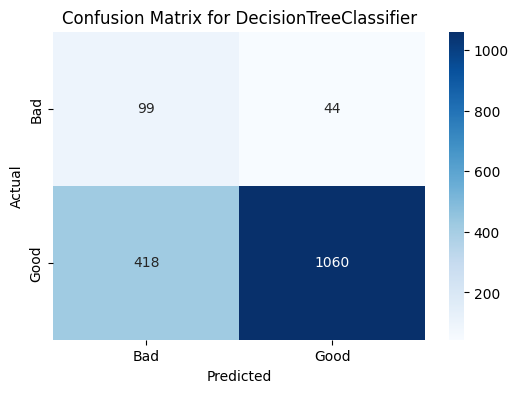

Classification Report for DecisionTreeClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.19      0.69      0.30       143
        Good       0.96      0.72      0.82      1478

    accuracy                           0.71      1621
   macro avg       0.58      0.70      0.56      1621
weighted avg       0.89      0.71      0.78      1621



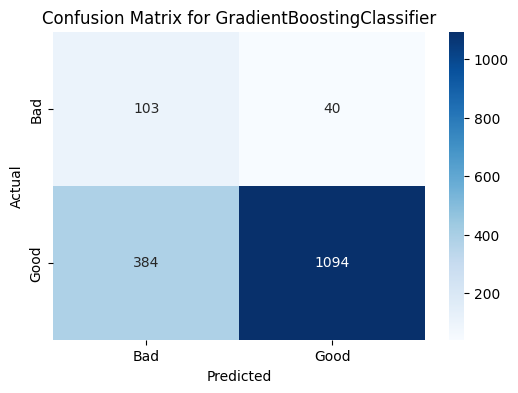

Classification Report for GradientBoostingClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.21      0.72      0.33       143
        Good       0.96      0.74      0.84      1478

    accuracy                           0.74      1621
   macro avg       0.59      0.73      0.58      1621
weighted avg       0.90      0.74      0.79      1621



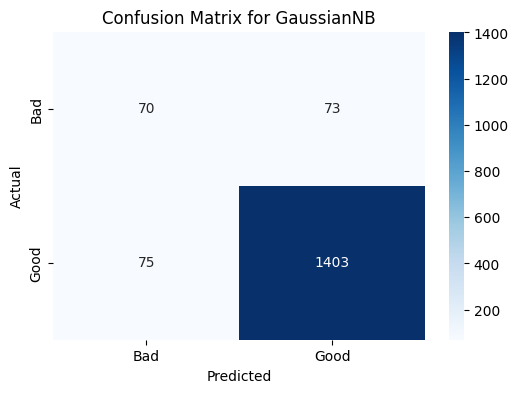

Classification Report for GaussianNB on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.48      0.49      0.49       143
        Good       0.95      0.95      0.95      1478

    accuracy                           0.91      1621
   macro avg       0.72      0.72      0.72      1621
weighted avg       0.91      0.91      0.91      1621



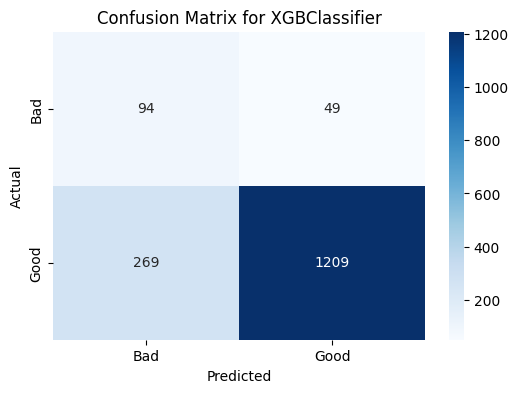

Classification Report for XGBClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.26      0.66      0.37       143
        Good       0.96      0.82      0.88      1478

    accuracy                           0.80      1621
   macro avg       0.61      0.74      0.63      1621
weighted avg       0.90      0.80      0.84      1621



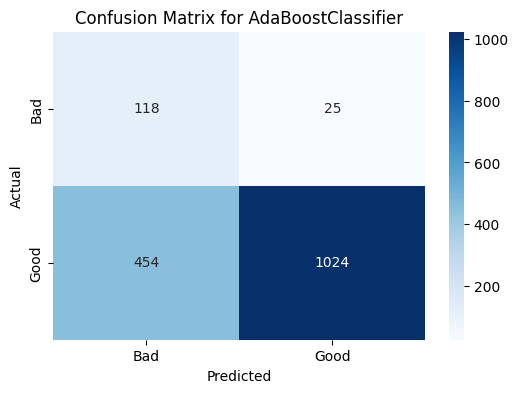

Classification Report for AdaBoostClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.21      0.83      0.33       143
        Good       0.98      0.69      0.81      1478

    accuracy                           0.70      1621
   macro avg       0.59      0.76      0.57      1621
weighted avg       0.91      0.70      0.77      1621



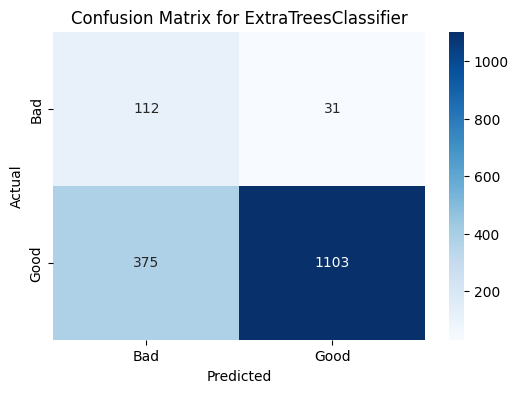

Classification Report for ExtraTreesClassifier on Unseen Data:

              precision    recall  f1-score   support

         Bad       0.23      0.78      0.36       143
        Good       0.97      0.75      0.84      1478

    accuracy                           0.75      1621
   macro avg       0.60      0.76      0.60      1621
weighted avg       0.91      0.75      0.80      1621



In [80]:
unseen_X_dec2jan_app, unseen_y_dec2jan_app = prepare_data(good_dec2, bad_dec2)
# Example usage
model_save_dir = '/kaggle/working/Classification models'
scaler_path = '/kaggle/working/Classification models/scaler_classification.pkl'  # Path to the saved scaler used during training

model_names = [
    "LogisticRegression", "RandomForestClassifier", "SVC", "KNeighborsClassifier",
    "DecisionTreeClassifier", "GradientBoostingClassifier", "GaussianNB",
    "XGBClassifier", "AdaBoostClassifier", "ExtraTreesClassifier"
]

# Evaluate all saved models on unseen data
load_and_evaluate_models(unseen_X_dec2jan_app, unseen_y_dec2jan_app, model_save_dir, model_names, scaler_path=scaler_path)